# Manual annotation merge and preliminary QC

This notebook links the current manual labels to the blinded S7 assignment map, preserves the original ordinal label, derives a fuzzy global-relationship score, and performs preliminary quality checks for the currently available annotators.

**Important:** these are preliminary diagnostics, not final consensus results. The notebook does not modify the original Excel file or the original assignment map.

Label coding:

- `1` = global relationship present
- `2` = uncertain
- `3` = global relationship absent
- `global_score = (3 - label) / 2`, giving `1.0`, `0.5`, and `0.0`

In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = str

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 200)

sns.set_theme(style='whitegrid', context='notebook')


def locate_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in candidates:
        if (root / 'D' / 'Global' / 'D_S7_annotation_assignment_sheets.ipynb').exists():
            return root
    raise FileNotFoundError('Could not locate D/Global/D_S7_annotation_assignment_sheets.ipynb')


REPO_ROOT = locate_repo_root()
GLOBAL_DIR = REPO_ROOT / 'D' / 'Global'
LABELS_PATH = GLOBAL_DIR / 'manual_global_relationship_labels.xlsx'
ASSIGNMENT_PATH = (
    GLOBAL_DIR / 'output' / 'S7_annotation_sheets' / 'researcher_only'
    / 'all_annotators_assignment_map.csv'
)
OUTPUT_DIR = GLOBAL_DIR / 'output' / 'S8_annotation_merge_and_qc'
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_CURRENT_LABELS = 700
VALID_LABELS = {1, 2, 3}
LABEL_ORDER = [1, 2, 3]
LABEL_NAMES = {1: 'Yes', 2: 'Uncertain', 3: 'No'}
LABEL_COLORS = {1: '#2E8B57', 2: '#E69F00', 3: '#C62828'}
HIGH_SNR_THRESHOLD = 10.0
KAPPA_WEIGHTS = 'linear'

for path in [LABELS_PATH, ASSIGNMENT_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

print(f'Labels:     {LABELS_PATH}')
print(f'Assignments:{ASSIGNMENT_PATH}')
print(f'Output:     {OUTPUT_DIR}')

Labels:     /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/manual_global_relationship_labels.xlsx
Assignments:/Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S7_annotation_sheets/researcher_only/all_annotators_assignment_map.csv
Output:     /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S8_annotation_merge_and_qc


## 1. Load labels and assignment metadata

The Excel `id` column is standardized to `plot_code`, and `value` is standardized to `label`. The assignment map remains unchanged on disk.

In [2]:
labels_raw = pd.read_excel(LABELS_PATH)
assignments_raw = pd.read_csv(ASSIGNMENT_PATH, low_memory=False)

required_label_columns = {'id', 'value'}
missing_label_columns = required_label_columns - set(labels_raw.columns)
if missing_label_columns:
    raise ValueError(f'Label workbook is missing columns: {sorted(missing_label_columns)}')
if 'plot_code' not in assignments_raw.columns:
    raise ValueError('Assignment map is missing plot_code.')

labels = labels_raw[['id', 'value']].rename(columns={'id': 'plot_code', 'value': 'label'}).copy()
labels['plot_code'] = labels['plot_code'].astype(str).str.strip().str.upper()
labels['label'] = pd.to_numeric(labels['label'], errors='coerce')

assignments = assignments_raw.copy()
assignments['plot_code'] = assignments['plot_code'].astype(str).str.strip().str.upper()

print(f'Label rows loaded: {len(labels):,}')
print(f'Assignment rows available: {len(assignments):,}')
display(labels.head(10))

Label rows loaded: 700
Assignment rows available: 1,500


,plot_code,label
0,A1,2
1,A2,3
2,A3,3
3,A4,2
4,A5,1
5,A6,2
6,A7,3
7,A8,2
8,A9,1
9,A10,1


## 2. Required validation checks

The notebook stops before writing any joined output if a required check fails:

1. all 700 label IDs match an assignment;
2. label IDs are unique;
3. every label is one of `1`, `2`, or `3`;
4. the plot-code prefix matches `annotator_id`.

Additional safeguards check the expected row count and uniqueness of assignment `plot_code`.

In [3]:
checks = []


def add_check(name: str, passed: bool, detail: str) -> None:
    checks.append({'check': name, 'passed': bool(passed), 'detail': str(detail)})


add_check(
    'Expected current label count',
    len(labels) == EXPECTED_CURRENT_LABELS,
    f'found {len(labels):,}; expected {EXPECTED_CURRENT_LABELS:,}',
)

duplicate_label_ids = labels.loc[labels['plot_code'].duplicated(keep=False), 'plot_code'].tolist()
add_check(
    'Label IDs are unique',
    len(duplicate_label_ids) == 0,
    'no duplicates' if not duplicate_label_ids else f'duplicates: {duplicate_label_ids[:20]}',
)

assignment_ids_unique = assignments['plot_code'].is_unique
add_check(
    'Assignment plot_code is unique',
    assignment_ids_unique,
    'unique' if assignment_ids_unique else 'duplicate plot_code values exist in assignment map',
)

invalid_label_rows = labels.loc[~labels['label'].isin(VALID_LABELS), ['plot_code', 'label']]
add_check(
    'Labels belong to {1, 2, 3}',
    invalid_label_rows.empty,
    'all valid' if invalid_label_rows.empty else invalid_label_rows.head(20).to_dict('records'),
)

assignment_id_set = set(assignments['plot_code'])
unmatched_ids = sorted(set(labels['plot_code']) - assignment_id_set)
add_check(
    'All label IDs match assignment plot_code',
    len(unmatched_ids) == 0,
    '700/700 matched' if not unmatched_ids else f'unmatched: {unmatched_ids[:30]}',
)

prefix_probe = labels.merge(
    assignments[['plot_code', 'annotator_id']],
    on='plot_code', how='left', validate='one_to_one', indicator=True,
)
prefix_probe['id_prefix'] = prefix_probe['plot_code'].str.extract(r'^([A-Z]+)', expand=False)
prefix_mismatch = prefix_probe.loc[
    prefix_probe['_merge'].eq('both')
    & prefix_probe['id_prefix'].ne(prefix_probe['annotator_id'].astype(str).str.upper()),
    ['plot_code', 'id_prefix', 'annotator_id'],
]
add_check(
    'ID prefix matches annotator_id',
    prefix_mismatch.empty,
    'all prefixes match' if prefix_mismatch.empty else prefix_mismatch.head(30).to_dict('records'),
)

validation_summary = pd.DataFrame(checks)
validation_summary.to_csv(OUTPUT_DIR / 'validation_summary.csv', index=False)
display(validation_summary)

failed_checks = validation_summary.loc[~validation_summary['passed']]
if not failed_checks.empty:
    raise ValueError('Required validation failed; see validation_summary.csv and the table above.')

labels['label'] = labels['label'].astype(int)
print('All required validation checks passed.')

,check,passed,detail
0,Expected current label count,True,found 700; expected 700
1,Label IDs are unique,True,no duplicates
2,Assignment plot_code is unique,True,unique
3,"Labels belong to {1, 2, 3}",True,all valid
4,All label IDs match assignment plot_code,True,700/700 matched
5,ID prefix matches annotator_id,True,all prefixes match


All required validation checks passed.


## 3. Join labels to cases and derive fuzzy global score

The joined long table retains the original ordinal `label` and adds `global_score`. All S7 metadata—including case ID, annotator, family, repeat, SNR, metrics, Null status, and generation parameters—is retained.

In [4]:
if 'label' in assignments.columns:
    if assignments['label'].notna().any():
        raise ValueError('The original assignment map already contains non-empty labels; refusing to overwrite them.')
    assignments = assignments.drop(columns=['label'])

joined = labels.merge(
    assignments,
    on='plot_code',
    how='left',
    validate='one_to_one',
)
joined['global_score'] = (3.0 - joined['label']) / 2.0

if joined['case_id'].isna().any():
    raise ValueError('At least one label row is missing case metadata after the join.')
if not joined['global_score'].isin([0.0, 0.5, 1.0]).all():
    raise ValueError('Unexpected global_score value.')
if joined.duplicated(['annotator_id', 'case_id']).any():
    duplicates = joined.loc[
        joined.duplicated(['annotator_id', 'case_id'], keep=False),
        ['plot_code', 'annotator_id', 'case_id'],
    ]
    raise ValueError(f'An annotator received the same case more than once:\n{duplicates}')

front = ['plot_code', 'label', 'global_score', 'case_id', 'annotator_id']
joined = joined[front + [column for column in joined.columns if column not in front]]
joined_path = OUTPUT_DIR / 'annotation_responses_joined.csv'
joined.to_csv(joined_path, index=False)

print(f'Joined responses written: {joined_path}')
print(f'Rows: {len(joined):,}; unique cases: {joined["case_id"].nunique():,}; annotators: {joined["annotator_id"].nunique()}')
display(joined[front + ['family_id', 'family_name', 'requested_snr', 'repeat', 'MIC', 'MEV', 'dCor', 'is_null']].head(10))

Joined responses written: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S8_annotation_merge_and_qc/annotation_responses_joined.csv
Rows: 700; unique cases: 451; annotators: 7


,plot_code,label,global_score,case_id,annotator_id,family_id,family_name,requested_snr,repeat,MIC,MEV,dCor,is_null
0,A1,2,0.5,S032109,A,F13,S-curve positive,0.8,2,0.511410,0.511410,0.653911,False
1,A2,3,0.0,S079572,A,F25,Multi-regime threshold,3.0,1,0.336544,0.336544,0.311952,False
2,A3,3,0.0,N017,A,Null,No relationship,NaN,17,0.155208,0.155208,0.052391,True
3,A4,2,0.5,S004627,A,F01,Linear positive,0.3,1,0.325975,0.325975,0.507666,False
4,A5,1,1.0,S018290,A,F05,Power concave positive,5.0,1,0.642802,0.642802,0.845551,False
5,A6,2,0.5,S004879,A,F01,Linear positive,1.5,2,0.597102,0.597102,0.770198,False
6,A7,3,0.0,S032094,A,F13,S-curve positive,0.3,2,0.353305,0.353305,0.476422,False
7,A8,2,0.5,S059167,A,F19,Spike,15.0,1,0.331498,0.331498,0.248050,False
8,A9,1,1.0,S004883,A,F01,Linear positive,2.0,2,0.656090,0.656090,0.807188,False
9,A10,1,1.0,S031896,A,F13,S-curve positive,2.0,1,0.776317,0.776317,0.796408,False


## 4. Current coverage

Coverage is descriptive only. Cases with one current label cannot contribute to inter-rater agreement until another response is available.

In [5]:
master_case_count = assignments['case_id'].nunique()
current_case_counts = joined.groupby('case_id').size().rename('n_current_raters')
coverage_distribution = (
    current_case_counts.value_counts().sort_index().rename_axis('n_current_raters')
    .rename('n_cases').reset_index()
)
coverage_summary = pd.DataFrame({
    'metric': [
        'current_label_rows', 'current_annotators', 'master_unique_cases',
        'currently_covered_cases', 'currently_uncovered_cases',
    ],
    'value': [
        len(joined), joined['annotator_id'].nunique(), master_case_count,
        joined['case_id'].nunique(), master_case_count - joined['case_id'].nunique(),
    ],
})
coverage_summary.to_csv(OUTPUT_DIR / 'coverage_summary.csv', index=False)
coverage_distribution.to_csv(OUTPUT_DIR / 'coverage_distribution.csv', index=False)
display(coverage_summary)
display(coverage_distribution)

,metric,value
0,current_label_rows,700
1,current_annotators,7
2,master_unique_cases,480
3,currently_covered_cases,451
4,currently_uncovered_cases,29


,n_current_raters,n_cases
0,1,215
1,2,224
2,3,11
3,4,1


## 5. Annotator label profiles

Differences in mean score or category use are diagnostic signals, not grounds for automatically excluding an annotator.

label,annotator_id,n_label_1,n_label_2,n_label_3,share_label_1,share_label_2,share_label_3,mean_global_score,mean_score_minus_overall
0,A,44,18,38,0.44,0.18,0.38,0.530,-0.039
1,B,78,0,22,0.78,0.00,0.22,0.780,0.211
2,C,55,2,43,0.55,0.02,0.43,0.560,-0.009
3,E,35,24,41,0.35,0.24,0.41,0.470,-0.099
4,F,57,18,25,0.57,0.18,0.25,0.660,0.091
5,G,35,17,48,0.35,0.17,0.48,0.435,-0.134
6,I,52,6,42,0.52,0.06,0.42,0.550,-0.019


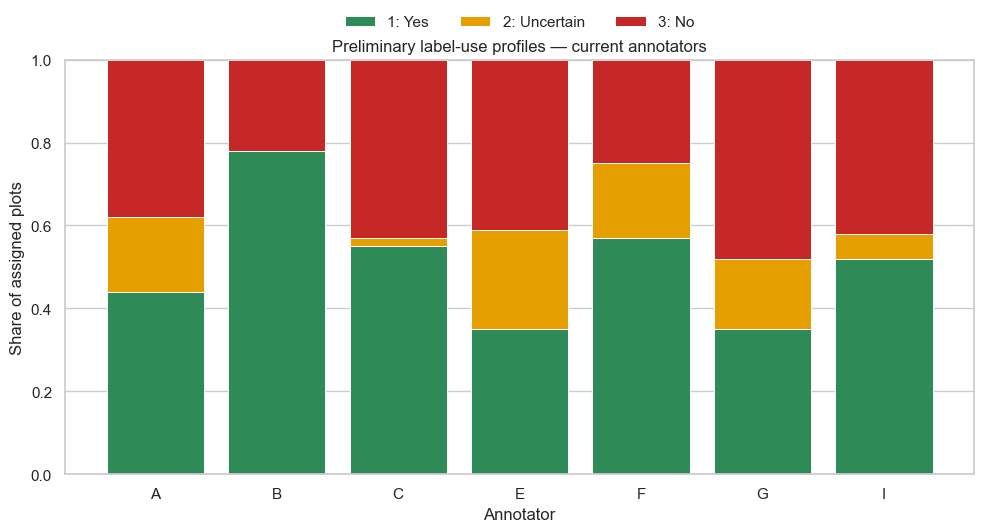

In [6]:
annotator_counts = (
    joined.groupby(['annotator_id', 'label']).size().unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
annotator_proportions = annotator_counts.div(annotator_counts.sum(axis=1), axis=0)
annotator_summary = annotator_counts.rename(columns={1: 'n_label_1', 2: 'n_label_2', 3: 'n_label_3'})
annotator_summary[['share_label_1', 'share_label_2', 'share_label_3']] = annotator_proportions.values
annotator_summary['mean_global_score'] = joined.groupby('annotator_id')['global_score'].mean()
overall_mean = joined['global_score'].mean()
annotator_summary['mean_score_minus_overall'] = annotator_summary['mean_global_score'] - overall_mean
annotator_summary = annotator_summary.reset_index()
annotator_summary.to_csv(OUTPUT_DIR / 'annotator_label_distribution.csv', index=False)
display(annotator_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(annotator_proportions))
for label in LABEL_ORDER:
    values = annotator_proportions[label].to_numpy()
    ax.bar(
        annotator_proportions.index, values, bottom=bottom,
        color=LABEL_COLORS[label], label=f'{label}: {LABEL_NAMES[label]}',
        edgecolor='white', linewidth=0.7,
    )
    bottom += values
ax.set_ylim(0, 1)
ax.set_ylabel('Share of assigned plots')
ax.set_xlabel('Annotator')
ax.set_title('Preliminary label-use profiles — current annotators')
ax.legend(ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.14))
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'annotator_label_profiles.png', dpi=220, bbox_inches='tight')
plt.show()

## 6. Per-annotator family × inverse-SNR label maps

Each current annotator receives one systematic overview. The layout is no longer the original A1–A100 display order:

- rows = function families
- columns = `1 / SNR`, ordered from small to large (noise increases from left to right)
- green = `1` (global relationship present)
- orange = `2` (uncertain)
- red = `3` (global relationship absent)

When the same annotator received both repeats for one family–SNR cell, the two original scatterplots are shown side by side inside that cell. Null controls have no SNR, so they are retained in a separate bottom strip. These figures show individual annotator responses, not consensus labels.


In [7]:
from matplotlib.lines import Line2D

POINTS_PATH = GLOBAL_DIR / 'output' / 'S3_snr_mic_sweep' / 'scatter_points.npz'
CONTACT_SHEET_DIR = FIGURE_DIR / 'annotator_contact_sheets'
CONTACT_SHEET_DIR.mkdir(parents=True, exist_ok=True)

CONTACT_DPI = 190
DISPLAY_CONTACT_SHEETS_IN_NOTEBOOK = True

FAMILY_ORDER = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18',
    'F21', 'F19', 'F23', 'F24', 'F25', 'F26', 'F22',
]
FAMILY_LABELS = {
    'F01': 'F01 Linear',
    'F03': 'F03 Power convex',
    'F05': 'F05 Power concave',
    'F07': 'F07 Saturation',
    'F13': 'F13 S-curve',
    'F15': 'F15 Threshold',
    'F18': 'F18 U-shape',
    'F21': 'F21 Cubic',
    'F19': 'F19 Spike',
    'F23': 'F23 Two Lines',
    'F24': 'F24 Line + Parabola',
    'F25': 'F25 Multi-regime',
    'F26': 'F26 Windowed J',
    'F22': 'F22 Oscillation',
}

# Ascending 1/SNR is the same as descending SNR: noise increases left to right.
SNR_ORDER = [100.0, 20.0, 15.0, 10.0, 7.0, 5.0, 4.0, 3.0,
             2.0, 1.5, 1.0, 0.8, 0.5, 0.4, 0.3, 0.1]

def compact_number(value: float) -> str:
    return f'{value:g}'

def inverse_snr_label(snr: float) -> str:
    inverse = 1.0 / snr
    if inverse < 0.1:
        inverse_text = f'{inverse:.3g}'
    else:
        inverse_text = f'{inverse:.3g}'
    return f'1/SNR {inverse_text}\n(SNR {compact_number(snr)})'

def bool_mask(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.astype(str).str.strip().str.lower().isin({'true', '1', 'yes'})

if not POINTS_PATH.exists():
    raise FileNotFoundError(POINTS_PATH)

observed_families = set(joined.loc[~bool_mask(joined['is_null']), 'family_id'].dropna())
if observed_families != set(FAMILY_ORDER):
    raise ValueError(
        'Family order does not match joined signal families: '
        f'missing={sorted(observed_families - set(FAMILY_ORDER))}, '
        f'extra={sorted(set(FAMILY_ORDER) - observed_families)}'
    )

observed_snr = set(
    joined.loc[~bool_mask(joined['is_null']), 'requested_snr'].dropna().astype(float)
)
if observed_snr != set(SNR_ORDER):
    raise ValueError(
        'SNR order does not match joined signal SNR levels: '
        f'missing={sorted(observed_snr - set(SNR_ORDER))}, '
        f'extra={sorted(set(SNR_ORDER) - observed_snr)}'
    )

# Remove the superseded display-order figures produced by the earlier layout.
for stale_path in CONTACT_SHEET_DIR.glob('annotator_*_colored_labels_10x10.png'):
    stale_path.unlink()

contact_sheet_records = []

with np.load(POINTS_PATH) as point_store:
    x_store = point_store['x']
    y_store = point_store['y']

    def style_empty_axis(ax):
        ax.set_facecolor('#FBFBFB')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        for spine in ax.spines.values():
            spine.set_color('#D7D7D7')
            spine.set_linewidth(0.38)

    def draw_record(ax, record, compact=False):
        candidate_index = int(record['candidate_index'])
        label = int(record['label'])
        color = LABEL_COLORS[label]
        x = x_store[candidate_index]
        y = y_store[candidate_index]

        ax.scatter(
            x, y,
            s=1.65 if not compact else 1.25,
            alpha=0.72,
            color=color,
            edgecolors='none',
            rasterized=True,
        )
        ax.set_xlim(-0.02, 1.02)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor('white')
        ax.text(
            0.025, 0.975,
            f"{record['plot_code']}  r{int(record['repeat'])}  [{label}]",
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=3.65 if compact else 4.15,
            fontweight='bold', color=color,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.22),
        )
        for spine in ax.spines.values():
            spine.set_color(color)
            spine.set_linewidth(0.85)

    for annotator_id in sorted(joined['annotator_id'].unique()):
        annotator_rows = (
            joined.loc[joined['annotator_id'].eq(annotator_id)]
            .sort_values('display_order')
            .reset_index(drop=True)
        )
        if len(annotator_rows) != 100:
            raise ValueError(f'Annotator {annotator_id} has {len(annotator_rows)} rows; expected 100.')

        null_mask = bool_mask(annotator_rows['is_null'])
        signal_rows = annotator_rows.loc[~null_mask].copy()
        null_rows = annotator_rows.loc[null_mask].sort_values('display_order').copy()

        cell_counts = signal_rows.groupby(['family_id', 'requested_snr']).size()
        if len(cell_counts) and int(cell_counts.max()) > 2:
            raise ValueError(
                f'Annotator {annotator_id} has more than two repeats in a family-SNR cell.'
            )

        fig = plt.figure(figsize=(28.0, 20.5), facecolor='white')
        grid = fig.add_gridspec(
            nrows=len(FAMILY_ORDER) + 1,
            ncols=len(SNR_ORDER),
            left=0.095, right=0.995,
            bottom=0.025, top=0.905,
            wspace=0.075, hspace=0.18,
            height_ratios=[1.0] * len(FAMILY_ORDER) + [1.0],
        )

        # Column labels explicitly use ascending 1/SNR; requested SNR is shown underneath.
        for column_index, snr in enumerate(SNR_ORDER):
            box = grid[0, column_index].get_position(fig)
            fig.text(
                (box.x0 + box.x1) / 2, box.y1 + 0.006,
                inverse_snr_label(snr),
                ha='center', va='bottom', fontsize=6.2, fontweight='bold',
            )

        occupied_cells = 0
        double_repeat_cells = 0
        for row_index, family_id in enumerate(FAMILY_ORDER):
            row_box = grid[row_index, 0].get_position(fig)
            fig.text(
                row_box.x0 - 0.006,
                (row_box.y0 + row_box.y1) / 2,
                FAMILY_LABELS[family_id],
                ha='right', va='center', fontsize=7.0, fontweight='bold',
            )

            family_rows = signal_rows.loc[signal_rows['family_id'].eq(family_id)]
            for column_index, snr in enumerate(SNR_ORDER):
                records = (
                    family_rows.loc[np.isclose(family_rows['requested_snr'].astype(float), snr)]
                    .sort_values(['repeat', 'display_order'])
                    .to_dict('records')
                )
                if not records:
                    ax = fig.add_subplot(grid[row_index, column_index])
                    style_empty_axis(ax)
                    continue

                occupied_cells += 1
                if len(records) == 1:
                    ax = fig.add_subplot(grid[row_index, column_index])
                    draw_record(ax, records[0])
                else:
                    double_repeat_cells += 1
                    subgrid = grid[row_index, column_index].subgridspec(
                        1, len(records), wspace=0.035
                    )
                    for repeat_index, record in enumerate(records):
                        ax = fig.add_subplot(subgrid[0, repeat_index])
                        draw_record(ax, record, compact=True)

        # Null cases have no meaningful SNR. Keep all of them, but separate them from the grid.
        null_row_index = len(FAMILY_ORDER)
        null_box = grid[null_row_index, 0].get_position(fig)
        fig.text(
            null_box.x0 - 0.006,
            (null_box.y0 + null_box.y1) / 2,
            'Null controls\n(no SNR)',
            ha='right', va='center', fontsize=7.0, fontweight='bold',
        )
        for column_index in range(len(SNR_ORDER)):
            if column_index < len(null_rows):
                ax = fig.add_subplot(grid[null_row_index, column_index])
                draw_record(ax, null_rows.iloc[column_index].to_dict())
            else:
                ax = fig.add_subplot(grid[null_row_index, column_index])
                ax.set_visible(False)

        legend_handles = [
            Line2D(
                [0], [0], marker='o', linestyle='none',
                markerfacecolor=LABEL_COLORS[label], markeredgecolor='none',
                markersize=7.0, label=f'{label}: {LABEL_NAMES[label]}',
            )
            for label in LABEL_ORDER
        ]
        fig.legend(
            handles=legend_handles,
            loc='upper center', ncol=3, frameon=False,
            bbox_to_anchor=(0.5, 0.956), fontsize=10,
        )
        fig.suptitle(
            f'Annotator {annotator_id} — function family × inverse SNR (noise increases →)',
            fontsize=14, y=0.986,
        )
        fig.text(
            0.5, 0.934,
            'Rows are function families; columns are ordered by increasing 1/SNR. '
            'Two assigned repeats in one cell are shown side by side.',
            ha='center', va='center', fontsize=8.4, color='#444444',
        )

        png_path = CONTACT_SHEET_DIR / f'annotator_{annotator_id}_family_by_inverse_snr.png'
        fig.savefig(png_path, dpi=CONTACT_DPI, facecolor='white')
        plt.close(fig)

        label_counts = annotator_rows['label'].value_counts().reindex(LABEL_ORDER, fill_value=0)
        contact_sheet_records.append({
            'annotator_id': annotator_id,
            'n_plots': len(annotator_rows),
            'n_signal_plots': len(signal_rows),
            'n_null_plots': len(null_rows),
            'n_occupied_family_snr_cells': occupied_cells,
            'n_double_repeat_cells': double_repeat_cells,
            'n_label_1': int(label_counts[1]),
            'n_label_2': int(label_counts[2]),
            'n_label_3': int(label_counts[3]),
            'figure_path': str(png_path),
        })

contact_sheet_manifest = pd.DataFrame(contact_sheet_records)
contact_sheet_manifest.to_csv(OUTPUT_DIR / 'annotator_contact_sheet_manifest.csv', index=False)
display(contact_sheet_manifest)

if DISPLAY_CONTACT_SHEETS_IN_NOTEBOOK:
    for record in contact_sheet_records:
        relative_path = Path(record['figure_path']).relative_to(GLOBAL_DIR)
        display(Markdown(
            f"**Annotator {record['annotator_id']}**  "
            f"(1: {record['n_label_1']}, 2: {record['n_label_2']}, 3: {record['n_label_3']}; "
            f"signal: {record['n_signal_plots']}, Null: {record['n_null_plots']})\n\n"
            f"![Annotator {record['annotator_id']} family by inverse SNR]({relative_path.as_posix()})"
        ))


,annotator_id,n_plots,n_signal_plots,n_null_plots,n_occupied_family_snr_cells,n_double_repeat_cells,n_label_1,n_label_2,n_label_3,figure_path
0,A,100,94,6,92,2,44,18,38,/Users/mimi/Documents/Code/Github/GSA-work/exp...
1,B,100,94,6,90,4,78,0,22,/Users/mimi/Documents/Code/Github/GSA-work/exp...
2,C,100,93,7,89,4,55,2,43,/Users/mimi/Documents/Code/Github/GSA-work/exp...
3,E,100,93,7,88,5,35,24,41,/Users/mimi/Documents/Code/Github/GSA-work/exp...
4,F,100,93,7,92,1,57,18,25,/Users/mimi/Documents/Code/Github/GSA-work/exp...
5,G,100,93,7,85,8,35,17,48,/Users/mimi/Documents/Code/Github/GSA-work/exp...
6,I,100,93,7,86,7,52,6,42,/Users/mimi/Documents/Code/Github/GSA-work/exp...


**Annotator A**  (1: 44, 2: 18, 3: 38; signal: 94, Null: 6)

![Annotator A family by inverse SNR](output/S8_annotation_merge_and_qc/figures/annotator_contact_sheets/annotator_A_family_by_inverse_snr.png)

**Annotator B**  (1: 78, 2: 0, 3: 22; signal: 94, Null: 6)

![Annotator B family by inverse SNR](output/S8_annotation_merge_and_qc/figures/annotator_contact_sheets/annotator_B_family_by_inverse_snr.png)

**Annotator C**  (1: 55, 2: 2, 3: 43; signal: 93, Null: 7)

![Annotator C family by inverse SNR](output/S8_annotation_merge_and_qc/figures/annotator_contact_sheets/annotator_C_family_by_inverse_snr.png)

**Annotator E**  (1: 35, 2: 24, 3: 41; signal: 93, Null: 7)

![Annotator E family by inverse SNR](output/S8_annotation_merge_and_qc/figures/annotator_contact_sheets/annotator_E_family_by_inverse_snr.png)

**Annotator F**  (1: 57, 2: 18, 3: 25; signal: 93, Null: 7)

![Annotator F family by inverse SNR](output/S8_annotation_merge_and_qc/figures/annotator_contact_sheets/annotator_F_family_by_inverse_snr.png)

**Annotator G**  (1: 35, 2: 17, 3: 48; signal: 93, Null: 7)

![Annotator G family by inverse SNR](output/S8_annotation_merge_and_qc/figures/annotator_contact_sheets/annotator_G_family_by_inverse_snr.png)

**Annotator I**  (1: 52, 2: 6, 3: 42; signal: 93, Null: 7)

![Annotator I family by inverse SNR](output/S8_annotation_merge_and_qc/figures/annotator_contact_sheets/annotator_I_family_by_inverse_snr.png)

## 7. Four combined group × repeat summaries

The combined overview is separated into four figures so that repeat 1 and repeat 2 never share a cell:

1. Group 1 — repeat 1
2. Group 1 — repeat 2
3. Group 2 — repeat 1
4. Group 2 — repeat 2

Within each figure, rows are function families and columns are increasing `1 / SNR`. Each cell therefore represents at most one original case. If several annotators assigned the same label to that case, their choice is collapsed into one colored scatterplot and their annotator IDs are listed together. Multiple colored versions appear only when annotators disagreed on that same case.

Null controls are not included because they have neither function family nor SNR; they remain visible in the per-annotator figures above.


In [8]:
GROUP_DEFINITIONS = {
    'Group 1': ['F01', 'F03', 'F05', 'F13', 'F15', 'F18', 'F21', 'F22'],
    'Group 2': ['F07', 'F19', 'F23', 'F24', 'F25', 'F26'],
}
REPEAT_ORDER = [1, 2]

COMBINED_GROUP_DIR = FIGURE_DIR / 'combined_group_label_maps'
COMBINED_GROUP_DIR.mkdir(parents=True, exist_ok=True)
COMBINED_GROUP_DPI = 200
DISPLAY_COMBINED_GROUPS_IN_NOTEBOOK = True

signal_joined = joined.loc[~bool_mask(joined['is_null'])].copy()

# One row per unique case × distinct response. Annotators agreeing on that response
# are listed together, so an identical choice is never drawn once per person.
combined_response_rows = []
for case_id, case_rows in signal_joined.groupby('case_id', sort=False):
    candidate_indices = case_rows['candidate_index'].dropna().astype(int).unique()
    family_ids = case_rows['family_id'].dropna().unique()
    snr_values = case_rows['requested_snr'].dropna().astype(float).unique()
    repeat_values = case_rows['repeat'].dropna().astype(int).unique()
    if not (
        len(candidate_indices) == len(family_ids) == len(snr_values) == len(repeat_values) == 1
    ):
        raise ValueError(f'Inconsistent metadata across assignments for case {case_id}.')

    for label, label_rows in case_rows.groupby('label', sort=True):
        annotators = sorted(label_rows['annotator_id'].astype(str).unique())
        plot_codes = sorted(label_rows['plot_code'].astype(str).unique())
        combined_response_rows.append({
            'case_id': case_id,
            'candidate_index': int(candidate_indices[0]),
            'family_id': str(family_ids[0]),
            'requested_snr': float(snr_values[0]),
            'repeat': int(repeat_values[0]),
            'label': int(label),
            'annotators': ','.join(annotators),
            'plot_codes': ','.join(plot_codes),
            'n_annotators': len(annotators),
        })

combined_response_map = pd.DataFrame(combined_response_rows)
family_to_group = {
    family_id: group_name
    for group_name, family_ids in GROUP_DEFINITIONS.items()
    for family_id in family_ids
}
combined_response_map['group_name'] = combined_response_map['family_id'].map(family_to_group)
if combined_response_map['group_name'].isna().any():
    missing = sorted(combined_response_map.loc[combined_response_map['group_name'].isna(), 'family_id'].unique())
    raise ValueError(f'Families missing from group definitions: {missing}')

combined_response_map = combined_response_map[
    ['group_name', 'family_id', 'requested_snr', 'repeat', 'case_id',
     'candidate_index', 'label', 'annotators', 'n_annotators', 'plot_codes']
].sort_values(['group_name', 'repeat', 'family_id', 'requested_snr', 'label'])
combined_response_map_path = OUTPUT_DIR / 'combined_group_case_response_map.csv'
combined_response_map.to_csv(combined_response_map_path, index=False)

# Remove the superseded figures in which both repeats shared one family-SNR cell.
for stale_name in [
    'group_1_combined_labels_by_inverse_snr.png',
    'group_2_combined_labels_by_inverse_snr.png',
]:
    stale_path = COMBINED_GROUP_DIR / stale_name
    if stale_path.exists():
        stale_path.unlink()

combined_group_records = []

with np.load(POINTS_PATH) as point_store:
    x_store = point_store['x']
    y_store = point_store['y']

    def style_combined_empty_axis(ax):
        ax.set_facecolor('#FBFBFB')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        for spine in ax.spines.values():
            spine.set_color('#D7D7D7')
            spine.set_linewidth(0.38)

    def draw_combined_response(ax, response, compact=False):
        label = int(response['label'])
        color = LABEL_COLORS[label]
        candidate_index = int(response['candidate_index'])
        x = x_store[candidate_index]
        y = y_store[candidate_index]
        annotator_text = str(response['annotators'])

        ax.scatter(
            x, y,
            s=1.58 if not compact else 1.15,
            alpha=0.72,
            color=color,
            edgecolors='none',
            rasterized=True,
        )
        ax.set_xlim(-0.02, 1.02)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor('white')
        ax.text(
            0.025, 0.975,
            f"{label}:{annotator_text}",
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=3.70 if compact else 4.25,
            fontweight='bold', color=color,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.76, pad=0.20),
        )
        for spine in ax.spines.values():
            spine.set_color(color)
            spine.set_linewidth(0.90)

    for group_name, group_families in GROUP_DEFINITIONS.items():
        for repeat_value in REPEAT_ORDER:
            figure_rows = combined_response_map.loc[
                combined_response_map['group_name'].eq(group_name)
                & combined_response_map['repeat'].eq(repeat_value)
            ].copy()

            figure_height = 2.0 + 1.48 * len(group_families)
            fig = plt.figure(figsize=(28.0, figure_height), facecolor='white')
            grid = fig.add_gridspec(
                nrows=len(group_families),
                ncols=len(SNR_ORDER),
                left=0.095, right=0.995,
                bottom=0.035, top=0.845,
                wspace=0.075, hspace=0.16,
            )

            for column_index, snr in enumerate(SNR_ORDER):
                box = grid[0, column_index].get_position(fig)
                fig.text(
                    (box.x0 + box.x1) / 2, box.y1 + 0.008,
                    inverse_snr_label(snr),
                    ha='center', va='bottom', fontsize=6.1, fontweight='bold',
                )

            n_outer_cells = 0
            n_disagreement_cases = 0
            max_distinct_labels = 0

            for row_index, family_id in enumerate(group_families):
                row_box = grid[row_index, 0].get_position(fig)
                fig.text(
                    row_box.x0 - 0.006,
                    (row_box.y0 + row_box.y1) / 2,
                    FAMILY_LABELS[family_id],
                    ha='right', va='center', fontsize=7.2, fontweight='bold',
                )

                family_rows = figure_rows.loc[figure_rows['family_id'].eq(family_id)]
                for column_index, snr in enumerate(SNR_ORDER):
                    cell_rows = family_rows.loc[
                        np.isclose(family_rows['requested_snr'].astype(float), snr)
                    ].sort_values('label')

                    if cell_rows.empty:
                        ax = fig.add_subplot(grid[row_index, column_index])
                        style_combined_empty_axis(ax)
                        continue

                    if cell_rows['case_id'].nunique() != 1:
                        raise ValueError(
                            f'{group_name}, repeat {repeat_value}, {family_id}, SNR {snr} '
                            'contains more than one original case.'
                        )

                    n_outer_cells += 1
                    response_records = cell_rows.to_dict('records')
                    n_distinct_labels = len(response_records)
                    max_distinct_labels = max(max_distinct_labels, n_distinct_labels)
                    n_disagreement_cases += int(n_distinct_labels > 1)

                    if n_distinct_labels == 1:
                        ax = fig.add_subplot(grid[row_index, column_index])
                        draw_combined_response(ax, response_records[0])
                    else:
                        subgrid = grid[row_index, column_index].subgridspec(
                            1, n_distinct_labels, wspace=0.035
                        )
                        for label_index, response in enumerate(response_records):
                            ax = fig.add_subplot(subgrid[0, label_index])
                            draw_combined_response(ax, response, compact=True)

            legend_handles = [
                Line2D(
                    [0], [0], marker='o', linestyle='none',
                    markerfacecolor=LABEL_COLORS[label], markeredgecolor='none',
                    markersize=7.0, label=f'{label}: {LABEL_NAMES[label]}',
                )
                for label in LABEL_ORDER
            ]
            fig.legend(
                handles=legend_handles,
                loc='upper center', ncol=3, frameon=False,
                bbox_to_anchor=(0.5, 0.935), fontsize=10,
            )
            fig.suptitle(
                f'{group_name} — repeat {repeat_value} — combined annotator choices',
                fontsize=14, y=0.985,
            )
            fig.text(
                0.5, 0.885,
                'One cell = one original case. Matching labels are collapsed '
                '(for example, 1:A,C,F); different labels are shown side by side. Noise increases →',
                ha='center', va='center', fontsize=8.5, color='#444444',
            )

            group_slug = group_name.lower().replace(' ', '_')
            png_path = (
                COMBINED_GROUP_DIR
                / f'{group_slug}_repeat_{repeat_value}_combined_labels_by_inverse_snr.png'
            )
            fig.savefig(png_path, dpi=COMBINED_GROUP_DPI, facecolor='white')
            plt.close(fig)

            combined_group_records.append({
                'group_name': group_name,
                'repeat': repeat_value,
                'n_families': len(group_families),
                'n_family_snr_cells_with_labels': n_outer_cells,
                'n_unique_cases': figure_rows['case_id'].nunique(),
                'n_case_response_panels': len(figure_rows),
                'n_cases_with_label_disagreement': n_disagreement_cases,
                'max_distinct_labels_on_one_case': max_distinct_labels,
                'figure_path': str(png_path),
            })

combined_group_manifest = pd.DataFrame(combined_group_records)
combined_group_manifest_path = OUTPUT_DIR / 'combined_group_label_map_manifest.csv'
combined_group_manifest.to_csv(combined_group_manifest_path, index=False)
display(combined_group_manifest)

if DISPLAY_COMBINED_GROUPS_IN_NOTEBOOK:
    for record in combined_group_records:
        relative_path = Path(record['figure_path']).relative_to(GLOBAL_DIR)
        display(Markdown(
            f"**{record['group_name']} — repeat {record['repeat']}** — "
            f"{record['n_unique_cases']} covered cases; "
            f"{record['n_cases_with_label_disagreement']} cases with different labels\n\n"
            f"![{record['group_name']} repeat {record['repeat']} combined choices]"
            f"({relative_path.as_posix()})"
        ))


,group_name,repeat,n_families,n_family_snr_cells_with_labels,n_unique_cases,n_case_response_panels,n_cases_with_label_disagreement,max_distinct_labels_on_one_case,figure_path
0,Group 1,1,8,122,122,143,21,2,/Users/mimi/Documents/Code/Github/GSA-work/exp...
1,Group 1,2,8,121,121,139,16,3,/Users/mimi/Documents/Code/Github/GSA-work/exp...
2,Group 2,1,6,91,91,106,15,2,/Users/mimi/Documents/Code/Github/GSA-work/exp...
3,Group 2,2,6,88,88,114,26,2,/Users/mimi/Documents/Code/Github/GSA-work/exp...


**Group 1 — repeat 1** — 122 covered cases; 21 cases with different labels

![Group 1 repeat 1 combined choices](output/S8_annotation_merge_and_qc/figures/combined_group_label_maps/group_1_repeat_1_combined_labels_by_inverse_snr.png)

**Group 1 — repeat 2** — 121 covered cases; 16 cases with different labels

![Group 1 repeat 2 combined choices](output/S8_annotation_merge_and_qc/figures/combined_group_label_maps/group_1_repeat_2_combined_labels_by_inverse_snr.png)

**Group 2 — repeat 1** — 91 covered cases; 15 cases with different labels

![Group 2 repeat 1 combined choices](output/S8_annotation_merge_and_qc/figures/combined_group_label_maps/group_2_repeat_1_combined_labels_by_inverse_snr.png)

**Group 2 — repeat 2** — 88 covered cases; 26 cases with different labels

![Group 2 repeat 2 combined choices](output/S8_annotation_merge_and_qc/figures/combined_group_label_maps/group_2_repeat_2_combined_labels_by_inverse_snr.png)

## 8. Preliminary family-specific perceptual ranges

The calculation and the color assignment are kept as separate steps:

1. map each individual response to a numerical score: `1 → 1.0`, `2 → 0.5`, `3 → 0.0`;
2. average responses within each generated case, producing a separate `repeat_1_score` and `repeat_2_score`;
3. average the two available repeat scores with equal weight:

   \[
   s_{family,SNR}=
rac{s_{repeat\,1}+s_{repeat\,2}}{2};
   \]

4. only after the final score has been calculated, assign a display color:
   - green: final score `>= 0.75`;
   - orange: `0.25 <` final score `< 0.75`;
   - red: final score `<= 0.25`.

No monotonic adjustment is applied. If only one repeat currently has human labels, its score is used provisionally and the cell is marked `C1`. The output table explicitly retains both repeat scores and the final score.


In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

FAMILY_CALIBRATION_DIR = FIGURE_DIR / 'family_snr_calibration'
FAMILY_CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

# Remove outputs from the superseded isotonic-calibration version.
for stale_path in [
    OUTPUT_DIR / 'family_snr_isotonic_scores.csv',
    OUTPUT_DIR / 'family_snr_consensus_scores.csv',
    FAMILY_CALIBRATION_DIR / 'family_snr_isotonic_score_heatmap.png',
]:
    if stale_path.exists():
        stale_path.unlink()

CASE_CONSENSUS_PATH = OUTPUT_DIR / 'case_level_annotation_consensus.csv'
FAMILY_SNR_SCORE_PATH = OUTPUT_DIR / 'family_snr_repeat_and_final_scores.csv'
MANUAL_CALIBRATION_PATH = OUTPUT_DIR / 'family_snr_manual_calibration.csv'

CLEAR_SCORE_THRESHOLD = 0.75
NO_DETECTABLE_SCORE_THRESHOLD = 0.25
FAMILY_CALIBRATION_DPI = 210
DISPLAY_FAMILY_CALIBRATION_IN_NOTEBOOK = True

PRELIMINARY_CLASS_NAMES = {
    1: 'clear global relationship',
    2: 'uncertain',
    3: 'no detectable global relationship',
}

def preliminary_label_from_score(score: float) -> int:
    if score >= CLEAR_SCORE_THRESHOLD:
        return 1
    if score <= NO_DETECTABLE_SCORE_THRESHOLD:
        return 3
    return 2

# -----------------------------------------------------------------------------
# 1. Case-level consensus: each original case is one unit of analysis.
# -----------------------------------------------------------------------------
case_consensus_records = []
for case_id, case_rows in joined.groupby('case_id', sort=False):
    metadata_columns = [
        'candidate_index', 'family_id', 'family_name', 'requested_snr',
        'inverse_snr', 'repeat', 'is_null', 'MIC', 'MEV', 'dCor',
    ]
    metadata = case_rows.iloc[0]
    for column in metadata_columns:
        non_missing = case_rows[column].dropna().unique()
        if len(non_missing) > 1:
            raise ValueError(f'Case {case_id} has inconsistent {column}: {non_missing}')

    labels_for_case = case_rows['label'].astype(int)
    scores_for_case = case_rows['global_score'].astype(float)
    case_consensus_records.append({
        'case_id': case_id,
        'candidate_index': int(metadata['candidate_index']),
        'family_id': metadata['family_id'],
        'family_name': metadata['family_name'],
        'requested_snr': metadata['requested_snr'],
        'inverse_snr': metadata['inverse_snr'],
        'repeat': int(metadata['repeat']),
        'is_null': bool_mask(pd.Series([metadata['is_null']])).iloc[0],
        'MIC': metadata['MIC'],
        'MEV': metadata['MEV'],
        'dCor': metadata['dCor'],
        'n_raters': int(case_rows['annotator_id'].nunique()),
        'n_label_1': int(labels_for_case.eq(1).sum()),
        'n_label_2': int(labels_for_case.eq(2).sum()),
        'n_label_3': int(labels_for_case.eq(3).sum()),
        'case_consensus_score': float(scores_for_case.mean()),
        'case_score_sd': float(scores_for_case.std(ddof=0)),
        'exact_agreement': bool(labels_for_case.nunique() == 1),
        'direct_1_vs_3_conflict': bool(labels_for_case.eq(1).any() and labels_for_case.eq(3).any()),
        'annotators': ','.join(sorted(case_rows['annotator_id'].astype(str).unique())),
        'plot_codes': ','.join(sorted(case_rows['plot_code'].astype(str).unique())),
        'labels': ','.join(str(value) for value in labels_for_case.tolist()),
    })

case_consensus = pd.DataFrame(case_consensus_records).sort_values(
    ['is_null', 'family_id', 'requested_snr', 'repeat', 'case_id'],
    na_position='last',
).reset_index(drop=True)
case_consensus.to_csv(CASE_CONSENSUS_PATH, index=False)

# -----------------------------------------------------------------------------
# 2. Calculate repeat 1 and repeat 2 scores separately, then average them.
# Color labels are not assigned until the final numerical score is available.
# -----------------------------------------------------------------------------
signal_case_consensus = case_consensus.loc[~case_consensus['is_null']].copy()
family_snr_records = []
for (family_id, requested_snr), cell_cases in signal_case_consensus.groupby(
    ['family_id', 'requested_snr'], sort=False
):
    repeat_scores = (
        cell_cases.groupby('repeat')['case_consensus_score']
        .mean()
        .sort_index()
    )
    repeat_1_score = (
        float(repeat_scores.loc[1]) if 1 in repeat_scores.index else np.nan
    )
    repeat_2_score = (
        float(repeat_scores.loc[2]) if 2 in repeat_scores.index else np.nan
    )
    available_repeat_scores = np.array(
        [repeat_1_score, repeat_2_score], dtype=float
    )
    final_consensus_score = float(
        np.nanmean(available_repeat_scores)
    )
    covered_repeat_values = sorted(
        cell_cases['repeat'].astype(int).unique()
    )

    family_snr_records.append({
        'family_id': family_id,
        'family_name': cell_cases['family_name'].iloc[0],
        'requested_snr': float(requested_snr),
        'inverse_snr': float(1.0 / requested_snr),
        'n_cases': int(cell_cases['case_id'].nunique()),
        'n_covered_repeats': int(np.isfinite(available_repeat_scores).sum()),
        'n_ratings': int(cell_cases['n_raters'].sum()),
        'n_label_1': int(cell_cases['n_label_1'].sum()),
        'n_label_2': int(cell_cases['n_label_2'].sum()),
        'n_label_3': int(cell_cases['n_label_3'].sum()),
        'n_disagreement_cases': int((~cell_cases['exact_agreement']).sum()),
        'n_direct_1_vs_3_conflicts': int(
            cell_cases['direct_1_vs_3_conflict'].sum()
        ),
        'repeat_1_score': repeat_1_score,
        'repeat_2_score': repeat_2_score,
        'final_consensus_score': final_consensus_score,
        'repeat_score_difference': (
            repeat_1_score - repeat_2_score
            if np.isfinite(repeat_1_score) and np.isfinite(repeat_2_score)
            else np.nan
        ),
        'case_score_sd': float(
            cell_cases['case_consensus_score'].std(ddof=0)
        ),
        'covered_repeats': ','.join(
            str(value) for value in covered_repeat_values
        ),
    })

family_snr_scores = pd.DataFrame(family_snr_records)
if len(family_snr_scores) != len(FAMILY_ORDER) * len(SNR_ORDER):
    raise ValueError(
        f'Expected {len(FAMILY_ORDER) * len(SNR_ORDER)} covered family-SNR cells; '
        f'found {len(family_snr_scores)}.'
    )

# Explicit QC: when both repeat scores exist, the final score must be their
# equal-weighted arithmetic mean.
both_repeats = family_snr_scores['n_covered_repeats'].eq(2)
expected_two_repeat_mean = (
    family_snr_scores.loc[both_repeats, 'repeat_1_score']
    + family_snr_scores.loc[both_repeats, 'repeat_2_score']
) / 2.0
if not np.allclose(
    family_snr_scores.loc[both_repeats, 'final_consensus_score'],
    expected_two_repeat_mean,
):
    raise ValueError(
        'At least one final family–SNR score is not the equal-weighted '
        'mean of repeat 1 and repeat 2.'
    )

# -----------------------------------------------------------------------------
# 3. Assign a display class only after the final score has been calculated.
# -----------------------------------------------------------------------------
family_snr_scores['preliminary_label'] = (
    family_snr_scores['final_consensus_score']
    .map(preliminary_label_from_score)
    .astype(int)
)
family_snr_scores['preliminary_class'] = (
    family_snr_scores['preliminary_label'].map(PRELIMINARY_CLASS_NAMES)
)
family_snr_scores['low_case_coverage'] = (
    family_snr_scores['n_covered_repeats'].lt(2)
)

family_index = {family_id: index for index, family_id in enumerate(FAMILY_ORDER)}
snr_index = {snr: index for index, snr in enumerate(SNR_ORDER)}
family_snr_scores['_family_order'] = family_snr_scores['family_id'].map(family_index)
family_snr_scores['_snr_order'] = family_snr_scores['requested_snr'].map(snr_index)
family_snr_scores = family_snr_scores.sort_values(['_family_order', '_snr_order']).drop(
    columns=['_family_order', '_snr_order']
).reset_index(drop=True)
family_snr_scores.to_csv(FAMILY_SNR_SCORE_PATH, index=False)

# Preserve future manual overrides across reruns. Automatic columns are refreshed;
# only manual_label and manual_note are carried forward by family + requested SNR.
manual_columns = ['family_id', 'requested_snr', 'manual_label', 'manual_note']
if MANUAL_CALIBRATION_PATH.exists():
    existing_manual = pd.read_csv(MANUAL_CALIBRATION_PATH)
    available_manual_columns = [column for column in manual_columns if column in existing_manual.columns]
    if {'family_id', 'requested_snr'}.issubset(available_manual_columns):
        existing_manual = existing_manual[available_manual_columns].copy()
    else:
        existing_manual = pd.DataFrame(columns=manual_columns)
else:
    existing_manual = pd.DataFrame(columns=manual_columns)

calibration_table = family_snr_scores.merge(
    existing_manual,
    on=['family_id', 'requested_snr'],
    how='left',
    validate='one_to_one',
)
if 'manual_label' not in calibration_table:
    calibration_table['manual_label'] = pd.NA
if 'manual_note' not in calibration_table:
    calibration_table['manual_note'] = pd.NA

manual_numeric = pd.to_numeric(calibration_table['manual_label'], errors='coerce')
invalid_manual = manual_numeric.notna() & ~manual_numeric.isin([1, 2, 3])
if invalid_manual.any():
    bad_rows = calibration_table.loc[invalid_manual, ['family_id', 'requested_snr', 'manual_label']]
    raise ValueError(f'manual_label must be blank or 1/2/3:\n{bad_rows}')

calibration_table['manual_label'] = manual_numeric.astype('Int64')
calibration_table['manual_override_applied'] = calibration_table['manual_label'].notna()
calibration_table['display_label'] = (
    calibration_table['manual_label']
    .fillna(calibration_table['preliminary_label'])
    .astype(int)
)
calibration_table['display_class'] = calibration_table['display_label'].map(
    PRELIMINARY_CLASS_NAMES
)
calibration_table.to_csv(MANUAL_CALIBRATION_PATH, index=False)

print(
    f'Case consensus: {len(case_consensus):,} currently covered cases; '
    f'{len(signal_case_consensus):,} signal and '
    f'{int(case_consensus["is_null"].sum()):,} Null.'
)
print(
    f'Family-SNR calibration: {len(calibration_table):,} cells; '
    f'{int(calibration_table["low_case_coverage"].sum()):,} cells currently have one labeled repeat.'
)
display(
    calibration_table[
        ['family_id', 'requested_snr', 'repeat_1_score',
         'repeat_2_score', 'final_consensus_score',
         'n_covered_repeats', 'n_ratings', 'preliminary_label',
         'manual_label', 'display_label']
    ].head(20)
)

# -----------------------------------------------------------------------------
# 4a. Compact score + color heatmap for manual calibration.
# -----------------------------------------------------------------------------
heatmap_labels = np.full((len(FAMILY_ORDER), len(SNR_ORDER)), np.nan)
heatmap_annotations = np.empty((len(FAMILY_ORDER), len(SNR_ORDER)), dtype=object)

for record in calibration_table.to_dict('records'):
    row_index = family_index[record['family_id']]
    column_index = snr_index[float(record['requested_snr'])]
    display_label = int(record['display_label'])
    heatmap_labels[row_index, column_index] = display_label - 1
    manual_mark = '*' if bool(record['manual_override_applied']) else ''
    heatmap_annotations[row_index, column_index] = (
        f"{float(record['final_consensus_score']):.2f}{manual_mark}\n"
        f"rep {int(record['n_covered_repeats'])}/2 · R{int(record['n_ratings'])}"
    )

calibration_cmap = ListedColormap([
    LABEL_COLORS[1], LABEL_COLORS[2], LABEL_COLORS[3]
])
fig, ax = plt.subplots(figsize=(25.0, 11.5), facecolor='white')
ax.imshow(heatmap_labels, cmap=calibration_cmap, vmin=-0.5, vmax=2.5, aspect='auto')

for row_index in range(len(FAMILY_ORDER)):
    for column_index in range(len(SNR_ORDER)):
        ax.text(
            column_index, row_index,
            heatmap_annotations[row_index, column_index],
            ha='center', va='center',
            fontsize=5.6, fontweight='bold', color='white',
        )

ax.set_xticks(range(len(SNR_ORDER)))
ax.set_xticklabels(
    [inverse_snr_label(snr) for snr in SNR_ORDER],
    fontsize=7.0,
)
ax.set_yticks(range(len(FAMILY_ORDER)))
ax.set_yticklabels(
    [FAMILY_LABELS[family_id] for family_id in FAMILY_ORDER],
    fontsize=8.0,
)
ax.set_xticks(np.arange(-0.5, len(SNR_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(FAMILY_ORDER), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.tick_params(axis='both', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_handles = [
    Patch(facecolor=LABEL_COLORS[label], edgecolor='none',
          label=f'{label}: {PRELIMINARY_CLASS_NAMES[label]}')
    for label in LABEL_ORDER
]
ax.legend(
    handles=legend_handles,
    loc='upper center', bbox_to_anchor=(0.5, 1.105),
    ncol=3, frameon=False, fontsize=10,
)
ax.set_title(
    'Actual family–SNR score before final color assignment',
    fontsize=14, pad=58,
)
ax.set_xlabel('1 / SNR (noise increases →)', fontsize=10, labelpad=12)
ax.set_ylabel('Function family', fontsize=10, labelpad=14)
fig.text(
    0.5, 0.925,
    'Cell text: actual final score; rep = contributing repeats, R = ratings. '
    'An asterisk marks a manual override.',
    ha='center', va='center', fontsize=9, color='#444444',
)
fig.subplots_adjust(left=0.12, right=0.995, bottom=0.08, top=0.82)

heatmap_path = FAMILY_CALIBRATION_DIR / 'family_snr_observed_consensus_score_heatmap.png'
fig.savefig(heatmap_path, dpi=FAMILY_CALIBRATION_DPI, facecolor='white')
plt.close(fig)

# -----------------------------------------------------------------------------
# 4b. Original scatterplots, repeat 1 and repeat 2 kept in separate figures.
#     The family-SNR color comes from the automatic/manual calibration table.
# -----------------------------------------------------------------------------
assignment_cases = assignments.drop_duplicates('case_id').copy()
assignment_signal_cases = assignment_cases.loc[~bool_mask(assignment_cases['is_null'])].copy()
assignment_null_cases = assignment_cases.loc[bool_mask(assignment_cases['is_null'])].copy()
if assignment_signal_cases['case_id'].nunique() != len(FAMILY_ORDER) * len(SNR_ORDER) * 2:
    raise ValueError('The assignment map does not contain the full 14 × 16 × 2 signal grid.')
if assignment_null_cases['case_id'].nunique() != 2 * len(SNR_ORDER):
    raise ValueError(
        f'Expected {2 * len(SNR_ORDER)} independent Null cases; '
        f'found {assignment_null_cases["case_id"].nunique()}.'
    )

# Null cases have no meaningful SNR and their stored repeat values are independent
# batch identifiers, not repeat 1/2. Sort the 32 Null controls by that identifier
# and use the first/second 16 only as display rows in the two repeat figures.
assignment_null_cases = assignment_null_cases.sort_values(
    ['repeat', 'case_id']
).reset_index(drop=True)
null_display_groups = {
    1: assignment_null_cases.iloc[:len(SNR_ORDER)].copy(),
    2: assignment_null_cases.iloc[len(SNR_ORDER):].copy(),
}
null_consensus_lookup = (
    case_consensus.loc[case_consensus['is_null']]
    .set_index('case_id')['case_consensus_score']
    .to_dict()
)
UNLABELLED_NULL_COLOR = '#8F8F8F'
null_display_manifest_records = []

calibration_lookup = calibration_table.set_index(['family_id', 'requested_snr'])
scatter_grid_records = []

with np.load(POINTS_PATH) as point_store:
    x_store = point_store['x']
    y_store = point_store['y']

    for repeat_value in [1, 2]:
        fig = plt.figure(figsize=(28.0, 21.8), facecolor='white')
        grid = fig.add_gridspec(
            nrows=len(FAMILY_ORDER) + 1,
            ncols=len(SNR_ORDER),
            left=0.095, right=0.995,
            bottom=0.025, top=0.895,
            wspace=0.075, hspace=0.18,
        )

        for column_index, snr in enumerate(SNR_ORDER):
            box = grid[0, column_index].get_position(fig)
            fig.text(
                (box.x0 + box.x1) / 2, box.y1 + 0.006,
                inverse_snr_label(snr),
                ha='center', va='bottom', fontsize=6.2, fontweight='bold',
            )

        for row_index, family_id in enumerate(FAMILY_ORDER):
            row_box = grid[row_index, 0].get_position(fig)
            fig.text(
                row_box.x0 - 0.006,
                (row_box.y0 + row_box.y1) / 2,
                FAMILY_LABELS[family_id],
                ha='right', va='center', fontsize=7.0, fontweight='bold',
            )

            for column_index, snr in enumerate(SNR_ORDER):
                case_rows = assignment_signal_cases.loc[
                    assignment_signal_cases['family_id'].eq(family_id)
                    & assignment_signal_cases['repeat'].eq(repeat_value)
                    & np.isclose(assignment_signal_cases['requested_snr'].astype(float), snr)
                ]
                if len(case_rows) != 1:
                    raise ValueError(
                        f'Expected one case for {family_id}, SNR {snr}, repeat {repeat_value}; '
                        f'found {len(case_rows)}.'
                    )

                case_record = case_rows.iloc[0]
                score_record = calibration_lookup.loc[(family_id, snr)]
                display_label = int(score_record['display_label'])
                color = LABEL_COLORS[display_label]
                candidate_index = int(case_record['candidate_index'])

                ax = fig.add_subplot(grid[row_index, column_index])
                ax.scatter(
                    x_store[candidate_index], y_store[candidate_index],
                    s=1.72, alpha=0.72, color=color,
                    edgecolors='none', rasterized=True,
                )
                ax.set_xlim(-0.02, 1.02)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_facecolor('white')
                manual_mark = '*' if bool(score_record['manual_override_applied']) else ''
                coverage_mark = ' · C1' if int(score_record['n_cases']) == 1 else ''
                ax.text(
                    0.025, 0.975,
                    f"score {float(score_record['final_consensus_score']):.2f}"
                    f"  → label {display_label}{manual_mark}{coverage_mark}",
                    transform=ax.transAxes,
                    ha='left', va='top', fontsize=4.05,
                    fontweight='bold', color=color,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.76, pad=0.20),
                )
                for spine in ax.spines.values():
                    spine.set_color(color)
                    spine.set_linewidth(0.90)

        # Add one Null-control row. Its 16 columns are display slots only:
        # Null cases do not have requested SNR values.
        null_row_index = len(FAMILY_ORDER)
        null_row_box = grid[null_row_index, 0].get_position(fig)
        fig.text(
            null_row_box.x0 - 0.006,
            (null_row_box.y0 + null_row_box.y1) / 2,
            'Null / No relationship\n(no SNR)',
            ha='right', va='center', fontsize=7.0, fontweight='bold',
        )
        null_group = null_display_groups[repeat_value]
        for column_index, (_, null_record) in enumerate(null_group.iterrows()):
            case_id = str(null_record['case_id'])
            candidate_index = int(null_record['candidate_index'])
            score = null_consensus_lookup.get(case_id, np.nan)
            if np.isfinite(score):
                display_label = preliminary_label_from_score(float(score))
                color = LABEL_COLORS[display_label]
                score_text = f'score {float(score):.2f} → label {display_label}'
                coverage_status = 'labelled'
            else:
                display_label = pd.NA
                color = UNLABELLED_NULL_COLOR
                score_text = 'not yet labelled'
                coverage_status = 'not_yet_labelled'

            ax = fig.add_subplot(grid[null_row_index, column_index])
            ax.scatter(
                x_store[candidate_index], y_store[candidate_index],
                s=1.72, alpha=0.72, color=color,
                edgecolors='none', rasterized=True,
            )
            ax.set_xlim(-0.02, 1.02)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor('white')
            ax.text(
                0.025, 0.975,
                f'{case_id} · {score_text}',
                transform=ax.transAxes,
                ha='left', va='top', fontsize=4.05,
                fontweight='bold', color=color,
                bbox=dict(
                    facecolor='white', edgecolor='none',
                    alpha=0.76, pad=0.20,
                ),
            )
            for spine in ax.spines.values():
                spine.set_color(color)
                spine.set_linewidth(0.90)

            null_display_manifest_records.append({
                'figure_repeat': repeat_value,
                'display_slot': column_index + 1,
                'case_id': case_id,
                'null_batch_id': int(null_record['repeat']),
                'candidate_index': candidate_index,
                'case_consensus_score': (
                    float(score) if np.isfinite(score) else np.nan
                ),
                'display_label': display_label,
                'coverage_status': coverage_status,
                'column_is_snr': False,
            })

        repeat_legend_handles = [
            *legend_handles,
            Patch(
                facecolor=UNLABELLED_NULL_COLOR, edgecolor='none',
                label='Null case not yet labelled',
            ),
        ]
        fig.legend(
            handles=repeat_legend_handles,
            loc='upper center', ncol=4, frameon=False,
            bbox_to_anchor=(0.5, 0.954), fontsize=10,
        )
        fig.suptitle(
            f'Preliminary family-specific calibration — repeat {repeat_value}',
            fontsize=14, y=0.986,
        )
        fig.text(
            0.5, 0.928,
            'Signal rows: columns show increasing 1/SNR and colors use the shared '
            'family–SNR consensus classification. Bottom row: independent Null controls; '
            'its columns are display slots only and do not denote SNR.',
            ha='center', va='center', fontsize=8.5, color='#444444',
        )

        scatter_path = (
            FAMILY_CALIBRATION_DIR
            / f'family_snr_manual_review_repeat_{repeat_value}.png'
        )
        fig.savefig(scatter_path, dpi=FAMILY_CALIBRATION_DPI, facecolor='white')
        plt.close(fig)
        scatter_grid_records.append({
            'repeat': repeat_value,
            'figure_path': str(scatter_path),
        })

null_display_manifest = pd.DataFrame(null_display_manifest_records)
null_display_manifest.to_csv(
    OUTPUT_DIR / 'null_control_rows_in_repeat_figures.csv',
    index=False,
)

family_calibration_figure_manifest = pd.DataFrame([
    {'figure_type': 'score_heatmap', 'repeat': pd.NA, 'figure_path': str(heatmap_path)},
    *[
        {'figure_type': 'scatter_grid', 'repeat': record['repeat'],
         'figure_path': record['figure_path']}
        for record in scatter_grid_records
    ],
])
family_calibration_figure_manifest.to_csv(
    OUTPUT_DIR / 'family_snr_calibration_figure_manifest.csv', index=False
)

if DISPLAY_FAMILY_CALIBRATION_IN_NOTEBOOK:
    heatmap_relative = heatmap_path.relative_to(GLOBAL_DIR)
    display(Markdown(
        f"**Preliminary score/color calibration**\n\n"
        f"![Family-SNR observed consensus score heatmap]({heatmap_relative.as_posix()})"
    ))
    for record in scatter_grid_records:
        relative_path = Path(record['figure_path']).relative_to(GLOBAL_DIR)
        display(Markdown(
            f"**Repeat {record['repeat']} — original scatterplots with preliminary colors**\n\n"
            f"![Family-SNR repeat {record['repeat']} manual review grid]"
            f"({relative_path.as_posix()})"
        ))


Case consensus: 451 currently covered cases; 422 signal and 29 Null.
Family-SNR calibration: 224 cells; 26 cells currently have one labeled repeat.


,family_id,requested_snr,repeat_1_score,repeat_2_score,final_consensus_score,n_covered_repeats,n_ratings,preliminary_label,manual_label,display_label
0,F01,100.0,1.0,1.0,1.00,2,2,1,<NA>,1
1,F01,20.0,1.0,1.0,1.00,2,4,1,<NA>,1
2,F01,15.0,1.0,1.0,1.00,2,4,1,<NA>,1
3,F01,10.0,1.0,1.0,1.00,2,2,1,<NA>,1
4,F01,7.0,1.0,1.0,1.00,2,3,1,<NA>,1
5,F01,5.0,1.0,1.0,1.00,2,3,1,<NA>,1
6,F01,4.0,1.0,NaN,1.00,1,1,1,<NA>,1
7,F01,3.0,1.0,1.0,1.00,2,3,1,<NA>,1
8,F01,2.0,1.0,1.0,1.00,2,4,1,<NA>,1
9,F01,1.5,1.0,0.5,0.75,2,3,1,<NA>,1


**Preliminary score/color calibration**

![Family-SNR observed consensus score heatmap](output/S8_annotation_merge_and_qc/figures/family_snr_calibration/family_snr_observed_consensus_score_heatmap.png)

**Repeat 1 — original scatterplots with preliminary colors**

![Family-SNR repeat 1 manual review grid](output/S8_annotation_merge_and_qc/figures/family_snr_calibration/family_snr_manual_review_repeat_1.png)

**Repeat 2 — original scatterplots with preliminary colors**

![Family-SNR repeat 2 manual review grid](output/S8_annotation_merge_and_qc/figures/family_snr_calibration/family_snr_manual_review_repeat_2.png)

### Actual final family–SNR score

The continuous score shown below is the value obtained **before color
assignment**. Different horizontal levels therefore represent different
calculated final scores, even when they receive the same color.

- red, orange, and green are applied only after the score is calculated;
- local reversals as noise increases are retained;
- `C1` means that only one repeat currently contributes a score.


In [10]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

REPEAT_AVERAGED_SCORE_HEATMAP_PATH = (
    FAMILY_CALIBRATION_DIR
    / 'family_snr_repeat_averaged_continuous_score_heatmap.png'
)

score_cmap = LinearSegmentedColormap.from_list(
    'human_consensus_red_yellow_green',
    [
        (0.00, '#C62828'),
        (0.50, '#F0B323'),
        (1.00, '#2E8B57'),
    ],
)
score_norm = Normalize(vmin=0.0, vmax=1.0)

continuous_score_matrix = np.full(
    (len(FAMILY_ORDER), len(SNR_ORDER)),
    np.nan,
)
continuous_score_annotations = np.empty(
    (len(FAMILY_ORDER), len(SNR_ORDER)),
    dtype=object,
)

for record in calibration_table.to_dict('records'):
    row_index = family_index[record['family_id']]
    column_index = snr_index[float(record['requested_snr'])]
    score = float(record['final_consensus_score'])
    continuous_score_matrix[row_index, column_index] = score
    coverage_mark = '\nC1' if int(record['n_cases']) == 1 else ''
    manual_mark = '*' if bool(record['manual_override_applied']) else ''
    continuous_score_annotations[row_index, column_index] = (
        f'{score:.2f}{manual_mark}{coverage_mark}'
    )

if np.isnan(continuous_score_matrix).any():
    raise ValueError('At least one family–SNR continuous score is missing.')

fig, ax = plt.subplots(figsize=(24.0, 10.5), facecolor='white')
image = ax.imshow(
    continuous_score_matrix,
    cmap=score_cmap,
    norm=score_norm,
    aspect='auto',
)

for row_index in range(len(FAMILY_ORDER)):
    for column_index in range(len(SNR_ORDER)):
        score = continuous_score_matrix[row_index, column_index]
        text_color = '#252525' if 0.24 < score < 0.78 else 'white'
        ax.text(
            column_index,
            row_index,
            continuous_score_annotations[row_index, column_index],
            ha='center',
            va='center',
            fontsize=7.0,
            fontweight='bold',
            color=text_color,
        )

ax.set_xticks(range(len(SNR_ORDER)))
ax.set_xticklabels(
    [inverse_snr_label(snr) for snr in SNR_ORDER],
    fontsize=7.0,
)
ax.set_yticks(range(len(FAMILY_ORDER)))
ax.set_yticklabels(
    [FAMILY_LABELS[family_id] for family_id in FAMILY_ORDER],
    fontsize=8.5,
)
ax.set_xticks(np.arange(-0.5, len(SNR_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(FAMILY_ORDER), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.25)
ax.tick_params(which='minor', bottom=False, left=False)
ax.tick_params(axis='both', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(
    image,
    ax=ax,
    orientation='vertical',
    fraction=0.018,
    pad=0.016,
    ticks=[0.0, 0.25, 0.5, 0.75, 1.0],
)
colorbar.set_label(
    'Actual final family–SNR score',
    fontsize=9,
    labelpad=9,
)
colorbar.ax.tick_params(labelsize=8, length=2)

ax.set_title(
    'Repeat-averaged family–SNR human-consensus score',
    fontsize=14,
    pad=56,
)
ax.set_xlabel(
    '1 / SNR (noise increases →)',
    fontsize=10,
    labelpad=12,
)
ax.set_ylabel(
    'Function family',
    fontsize=10,
    labelpad=14,
)
fig.text(
    0.5,
    0.922,
    'Labels are averaged within each case and then across repeat 1 and repeat 2. '
    'Color shows the family-specific observed score; C1 = only one labeled repeat.',
    ha='center',
    va='center',
    fontsize=9,
    color='#444444',
)
fig.subplots_adjust(
    left=0.12,
    right=0.95,
    bottom=0.095,
    top=0.82,
)
fig.savefig(
    REPEAT_AVERAGED_SCORE_HEATMAP_PATH,
    dpi=FAMILY_CALIBRATION_DPI,
    facecolor='white',
)
plt.close(fig)

# -----------------------------------------------------------------------------
# Pooled-repeat scatterplot grid: one subplot per family–SNR cell.
# The original points from repeat 1 and repeat 2 are pooled, not coordinate-
# averaged, so the display does not artificially reduce the noise.
# -----------------------------------------------------------------------------
POOLED_REPEATS_SCATTER_GRID_PATH = (
    FAMILY_CALIBRATION_DIR
    / 'family_snr_combined_repeats_continuous_score.png'
)

case_lookup = assignment_signal_cases.set_index(
    ['family_id', 'requested_snr', 'repeat']
)
if not case_lookup.index.is_unique:
    raise ValueError('Expected one generated case per family–SNR–repeat.')

fig = plt.figure(figsize=(28.0, 20.5), facecolor='white')
scatter_grid = fig.add_gridspec(
    nrows=len(FAMILY_ORDER),
    ncols=len(SNR_ORDER),
    left=0.095, right=0.995,
    bottom=0.025, top=0.835,
    wspace=0.085, hspace=0.18,
)

with np.load(POINTS_PATH) as point_store:
    x_store = point_store['x']
    y_store = point_store['y']

    for column_index, snr in enumerate(SNR_ORDER):
        box = scatter_grid[0, column_index].get_position(fig)
        fig.text(
            (box.x0 + box.x1) / 2,
            box.y1 + 0.006,
            inverse_snr_label(snr),
            ha='center',
            va='bottom',
            fontsize=6.2,
            fontweight='bold',
        )

    for row_index, family_id in enumerate(FAMILY_ORDER):
        row_box = scatter_grid[row_index, 0].get_position(fig)
        fig.text(
            row_box.x0 - 0.006,
            (row_box.y0 + row_box.y1) / 2,
            FAMILY_LABELS[family_id],
            ha='right',
            va='center',
            fontsize=7.0,
            fontweight='bold',
        )

        for column_index, snr in enumerate(SNR_ORDER):
            score_record = calibration_lookup.loc[(family_id, snr)]
            score = float(score_record['final_consensus_score'])
            score_color = score_cmap(score_norm(score))
            coverage_mark = ' C1' if int(score_record['n_cases']) == 1 else ''
            manual_mark = '*' if bool(score_record['manual_override_applied']) else ''

            repeat_records = [
                case_lookup.loc[(family_id, snr, repeat_value)]
                for repeat_value in [1, 2]
            ]
            candidate_indices = [
                int(record['candidate_index'])
                for record in repeat_records
            ]
            pooled_x = np.concatenate(
                [x_store[index] for index in candidate_indices]
            )
            pooled_y = np.concatenate(
                [y_store[index] for index in candidate_indices]
            )

            ax = fig.add_subplot(scatter_grid[row_index, column_index])
            ax.scatter(
                pooled_x,
                pooled_y,
                s=1.18,
                alpha=0.58,
                color=score_color,
                edgecolors='none',
                rasterized=True,
            )
            ax.set_xlim(-0.02, 1.02)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor('white')
            ax.text(
                0.975,
                0.975,
                f'{score:.2f}{manual_mark}{coverage_mark}',
                transform=ax.transAxes,
                ha='right',
                va='top',
                fontsize=4.15,
                fontweight='bold',
                color='#303030',
                bbox=dict(
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.82,
                    pad=0.18,
                ),
            )
            for spine in ax.spines.values():
                spine.set_color(score_color)
                spine.set_linewidth(0.95)

fig.suptitle(
    'Original scatterplots pooled across repeats — continuous consensus score',
    fontsize=14,
    y=0.985,
)
fig.text(
    0.5,
    0.945,
    'Each family–SNR panel pools the original points from repeat 1 and repeat 2. '
    'Color and the displayed value use the shared repeat-averaged observed score; '
    'C1 = only one labeled repeat.',
    ha='center',
    va='center',
    fontsize=8.8,
    color='#444444',
)

colorbar_ax = fig.add_axes([0.36, 0.897, 0.28, 0.012])
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=score_norm, cmap=score_cmap),
    cax=colorbar_ax,
    orientation='horizontal',
    ticks=[0.0, 0.25, 0.5, 0.75, 1.0],
)
colorbar.ax.tick_params(axis='x', labelsize=7, length=2)
colorbar.set_label(
    'Actual final family–SNR score',
    fontsize=8,
    labelpad=2,
)

fig.savefig(
    POOLED_REPEATS_SCATTER_GRID_PATH,
    dpi=FAMILY_CALIBRATION_DPI,
    facecolor='white',
)
plt.close(fig)

continuous_manifest_rows = pd.DataFrame([
    {
        'figure_type': 'repeat_averaged_continuous_score_heatmap',
        'repeat': pd.NA,
        'figure_path': str(REPEAT_AVERAGED_SCORE_HEATMAP_PATH),
    },
    {
        'figure_type': 'pooled_repeat_continuous_score_scatter_grid',
        'repeat': 'pooled_1+2',
        'figure_path': str(POOLED_REPEATS_SCATTER_GRID_PATH),
    },
])
family_calibration_figure_manifest = pd.concat(
    [family_calibration_figure_manifest, continuous_manifest_rows],
    ignore_index=True,
)
family_calibration_figure_manifest.to_csv(
    OUTPUT_DIR / 'family_snr_calibration_figure_manifest.csv',
    index=False,
)

if DISPLAY_FAMILY_CALIBRATION_IN_NOTEBOOK:
    heatmap_relative = REPEAT_AVERAGED_SCORE_HEATMAP_PATH.relative_to(GLOBAL_DIR)
    scatter_relative = POOLED_REPEATS_SCATTER_GRID_PATH.relative_to(GLOBAL_DIR)
    display(Markdown(
        '**Repeat-averaged continuous calibrated scores**\n\n'
        f'![Repeat-averaged continuous family-SNR score heatmap]'
        f'({heatmap_relative.as_posix()})'
    ))
    display(Markdown(
        '**Both repeats pooled into one scatterplot per family–SNR cell**\n\n'
        f'![Pooled-repeat continuous family-SNR scatterplot grid]'
        f'({scatter_relative.as_posix()})'
    ))

print(
    'Saved repeat-averaged continuous score heatmap: '
    f'{REPEAT_AVERAGED_SCORE_HEATMAP_PATH}'
)
print(
    'Saved pooled-repeat continuous score scatterplot grid: '
    f'{POOLED_REPEATS_SCATTER_GRID_PATH}'
)

**Repeat-averaged continuous calibrated scores**

![Repeat-averaged continuous family-SNR score heatmap](output/S8_annotation_merge_and_qc/figures/family_snr_calibration/family_snr_repeat_averaged_continuous_score_heatmap.png)

**Both repeats pooled into one scatterplot per family–SNR cell**

![Pooled-repeat continuous family-SNR scatterplot grid](output/S8_annotation_merge_and_qc/figures/family_snr_calibration/family_snr_combined_repeats_continuous_score.png)

Saved repeat-averaged continuous score heatmap: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S8_annotation_merge_and_qc/figures/family_snr_calibration/family_snr_repeat_averaged_continuous_score_heatmap.png
Saved pooled-repeat continuous score scatterplot grid: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S8_annotation_merge_and_qc/figures/family_snr_calibration/family_snr_combined_repeats_continuous_score.png


## 9. Final presentation grid and family-specific MIC ranges

The presentation grid uses the observed family–SNR consensus classification from the previous section. Each cell is colored by the common score rule and reports:

- the mean MIC of the two generated repeat cases at that family–SNR level;
- the observed human-consensus score used for classification.

The accompanying table reports **family-specific extended MIC ranges** based on the two-repeat mean MIC values:

- `No detectable relationship` extends from the minimum MIC observed for that family to the largest MIC observed among its `No` cells;
- `Uncertain` retains the observed minimum–maximum MIC range of its uncertain cells;
- `Clear relationship` extends from the smallest MIC observed among its `Clear` cells to the maximum MIC observed for that family.

If a region is never observed for a family, it remains `not observed`. The original within-region observed MIC endpoints are also retained in the long-form CSV for transparency. These ranges are family-specific and should not be interpreted as universal MIC cutoffs.


In [11]:
FINAL_MIC_GRID_PATH = (
    FAMILY_CALIBRATION_DIR / 'final_family_perceptual_ranges_with_mic.png'
)
FINAL_MIC_TABLE_FIGURE_PATH = (
    FAMILY_CALIBRATION_DIR / 'final_family_three_region_mic_ranges_table.png'
)
FINAL_FAMILY_SNR_TABLE_PATH = OUTPUT_DIR / 'final_family_snr_ranges_with_mic.csv'
MIC_RANGES_LONG_PATH = OUTPUT_DIR / 'family_three_region_mic_ranges_long.csv'
MIC_RANGES_WIDE_PATH = OUTPUT_DIR / 'family_three_region_mic_ranges.csv'

REGION_SHORT_NAMES = {
    1: 'clear',
    2: 'uncertain',
    3: 'no_detectable',
}
REGION_DISPLAY_NAMES = {
    1: 'Clear relationship',
    2: 'Uncertain',
    3: 'No detectable relationship',
}

# Every family-SNR level has two generated repeat cases. Average MIC across those
# two cases before summarising the three perceptual regions.
mic_cell_records = []
for (family_id, requested_snr), repeat_cases in assignment_signal_cases.groupby(
    ['family_id', 'requested_snr'], sort=False
):
    repeat_cases = repeat_cases.drop_duplicates('case_id')
    if repeat_cases['case_id'].nunique() != 2 or set(repeat_cases['repeat'].astype(int)) != {1, 2}:
        raise ValueError(
            f'{family_id}, SNR {requested_snr} does not contain exactly repeat 1 and repeat 2.'
        )
    mic_values = repeat_cases['MIC'].astype(float)
    if mic_values.isna().any():
        raise ValueError(f'Missing MIC for {family_id}, SNR {requested_snr}.')
    mic_cell_records.append({
        'family_id': family_id,
        'requested_snr': float(requested_snr),
        'inverse_snr': float(1.0 / requested_snr),
        'n_generated_repeats': int(repeat_cases['case_id'].nunique()),
        'repeat_mean_MIC': float(mic_values.mean()),
        'repeat_min_MIC': float(mic_values.min()),
        'repeat_max_MIC': float(mic_values.max()),
        'repeat_1_MIC': float(repeat_cases.loc[repeat_cases['repeat'].eq(1), 'MIC'].iloc[0]),
        'repeat_2_MIC': float(repeat_cases.loc[repeat_cases['repeat'].eq(2), 'MIC'].iloc[0]),
    })

mic_by_family_snr = pd.DataFrame(mic_cell_records)
if len(mic_by_family_snr) != len(FAMILY_ORDER) * len(SNR_ORDER):
    raise ValueError(
        f'Expected {len(FAMILY_ORDER) * len(SNR_ORDER)} family-SNR MIC cells; '
        f'found {len(mic_by_family_snr)}.'
    )

final_family_snr = calibration_table.merge(
    mic_by_family_snr,
    on=['family_id', 'requested_snr', 'inverse_snr'],
    how='left',
    validate='one_to_one',
)
if final_family_snr['repeat_mean_MIC'].isna().any():
    raise ValueError('At least one family-SNR calibration cell is missing repeat-mean MIC.')

final_family_snr['region_name'] = final_family_snr['display_label'].map(REGION_SHORT_NAMES)
final_family_snr['_family_order'] = final_family_snr['family_id'].map(family_index)
final_family_snr['_snr_order'] = final_family_snr['requested_snr'].map(snr_index)
final_family_snr = final_family_snr.sort_values(['_family_order', '_snr_order']).drop(
    columns=['_family_order', '_snr_order']
).reset_index(drop=True)
final_family_snr.to_csv(FINAL_FAMILY_SNR_TABLE_PATH, index=False)

# Long-form family-specific MIC range summary. Preserve the observed
# within-region endpoints, then extend only the two outer regions:
#   No    -> family minimum through observed No maximum
#   Clear -> observed Clear minimum through family maximum
# Uncertain remains its observed min-max range.
mic_range_records = []
for family_id in FAMILY_ORDER:
    family_rows = final_family_snr.loc[final_family_snr['family_id'].eq(family_id)]
    family_mic_values = family_rows['repeat_mean_MIC'].astype(float)
    family_mic_min = float(family_mic_values.min())
    family_mic_max = float(family_mic_values.max())

    for label in LABEL_ORDER:
        region_rows = family_rows.loc[family_rows['display_label'].eq(label)].copy()
        record = {
            'family_id': family_id,
            'family_name': FAMILY_LABELS[family_id],
            'label': label,
            'region_name': REGION_SHORT_NAMES[label],
            'region_display_name': REGION_DISPLAY_NAMES[label],
            'n_snr_levels': int(len(region_rows)),
            'family_mic_min': family_mic_min,
            'family_mic_max': family_mic_max,
        }
        if region_rows.empty:
            record.update({
                'snr_min': np.nan,
                'snr_max': np.nan,
                'inverse_snr_min': np.nan,
                'inverse_snr_max': np.nan,
                'observed_mic_min': np.nan,
                'observed_mic_max': np.nan,
                'mic_min': np.nan,
                'mic_max': np.nan,
                'mic_median': np.nan,
                'mic_mean': np.nan,
                'range_extension_rule': 'not_observed',
            })
        else:
            mic_values = region_rows['repeat_mean_MIC'].astype(float)
            observed_mic_min = float(mic_values.min())
            observed_mic_max = float(mic_values.max())

            if label == 1:  # Clear: extend upward to this family's maximum MIC.
                extended_mic_min = observed_mic_min
                extended_mic_max = family_mic_max
                extension_rule = 'observed_clear_min_to_family_max'
            elif label == 3:  # No: extend downward to this family's minimum MIC.
                extended_mic_min = family_mic_min
                extended_mic_max = observed_mic_max
                extension_rule = 'family_min_to_observed_no_max'
            else:  # Uncertain: retain the observed range.
                extended_mic_min = observed_mic_min
                extended_mic_max = observed_mic_max
                extension_rule = 'observed_uncertain_min_to_max'

            record.update({
                'snr_min': float(region_rows['requested_snr'].min()),
                'snr_max': float(region_rows['requested_snr'].max()),
                'inverse_snr_min': float(region_rows['inverse_snr'].min()),
                'inverse_snr_max': float(region_rows['inverse_snr'].max()),
                'observed_mic_min': observed_mic_min,
                'observed_mic_max': observed_mic_max,
                'mic_min': extended_mic_min,
                'mic_max': extended_mic_max,
                'mic_median': float(mic_values.median()),
                'mic_mean': float(mic_values.mean()),
                'range_extension_rule': extension_rule,
            })
        mic_range_records.append(record)

family_mic_ranges_long = pd.DataFrame(mic_range_records)

# Sanity checks for the requested tail-extension rule.
observed_regions = family_mic_ranges_long['n_snr_levels'].gt(0)
clear_rows = family_mic_ranges_long.loc[observed_regions & family_mic_ranges_long['label'].eq(1)]
no_rows = family_mic_ranges_long.loc[observed_regions & family_mic_ranges_long['label'].eq(3)]
assert np.allclose(clear_rows['mic_max'], clear_rows['family_mic_max'])
assert np.allclose(no_rows['mic_min'], no_rows['family_mic_min'])
assert (family_mic_ranges_long.loc[observed_regions, 'mic_min'] <=
        family_mic_ranges_long.loc[observed_regions, 'mic_max']).all()

family_mic_ranges_long.to_csv(MIC_RANGES_LONG_PATH, index=False)

def format_mic_range(region_rows: pd.DataFrame) -> str:
    if region_rows.empty:
        return 'not observed'
    n_levels = int(region_rows['n_snr_levels'].iloc[0])
    low = region_rows['mic_min'].iloc[0]
    high = region_rows['mic_max'].iloc[0]
    if n_levels == 0 or pd.isna(low) or pd.isna(high):
        return 'not observed'
    low = float(low)
    high = float(high)
    if np.isclose(low, high):
        return f'{low:.3f} (n={n_levels})'
    return f'{low:.3f}–{high:.3f} (n={n_levels})'

# Wide presentation table with both readable strings and numeric endpoints.
mic_range_wide_records = []
for family_id in FAMILY_ORDER:
    family_regions = family_mic_ranges_long.loc[
        family_mic_ranges_long['family_id'].eq(family_id)
    ]
    row = {
        'family_id': family_id,
        'family_name': FAMILY_LABELS[family_id],
    }
    for label in LABEL_ORDER:
        region_key = REGION_SHORT_NAMES[label]
        region_rows = family_regions.loc[family_regions['label'].eq(label)]
        row[f'{region_key}_mic_range'] = format_mic_range(region_rows)
        row[f'{region_key}_mic_min'] = region_rows['mic_min'].iloc[0]
        row[f'{region_key}_mic_max'] = region_rows['mic_max'].iloc[0]
        row[f'{region_key}_n_snr_levels'] = int(region_rows['n_snr_levels'].iloc[0])
    mic_range_wide_records.append(row)

family_mic_ranges = pd.DataFrame(mic_range_wide_records)
family_mic_ranges.to_csv(MIC_RANGES_WIDE_PATH, index=False)
display(
    family_mic_ranges[
        ['family_id', 'family_name', 'clear_mic_range',
         'uncertain_mic_range', 'no_detectable_mic_range']
    ]
)

# -----------------------------------------------------------------------------
# Final presentation grid: color = perceptual region; text = repeat-mean MIC
# and the actual final family–SNR score used before color assignment.
# -----------------------------------------------------------------------------
final_color_matrix = np.full((len(FAMILY_ORDER), len(SNR_ORDER)), np.nan)
final_annotations = np.empty((len(FAMILY_ORDER), len(SNR_ORDER)), dtype=object)

for record in final_family_snr.to_dict('records'):
    row_index = family_index[record['family_id']]
    column_index = snr_index[float(record['requested_snr'])]
    display_label = int(record['display_label'])
    final_color_matrix[row_index, column_index] = display_label - 1
    manual_mark = '*' if bool(record['manual_override_applied']) else ''
    final_annotations[row_index, column_index] = (
        f"MIC {float(record['repeat_mean_MIC']):.3f}\n"
        f"score {float(record['final_consensus_score']):.2f}{manual_mark}"
    )

fig, ax = plt.subplots(figsize=(25.0, 11.2), facecolor='white')
ax.imshow(final_color_matrix, cmap=calibration_cmap, vmin=-0.5, vmax=2.5, aspect='auto')

for row_index in range(len(FAMILY_ORDER)):
    for column_index in range(len(SNR_ORDER)):
        ax.text(
            column_index, row_index,
            final_annotations[row_index, column_index],
            ha='center', va='center',
            fontsize=6.0, fontweight='bold', color='white',
        )

ax.set_xticks(range(len(SNR_ORDER)))
ax.set_xticklabels([inverse_snr_label(snr) for snr in SNR_ORDER], fontsize=7.0)
ax.set_yticks(range(len(FAMILY_ORDER)))
ax.set_yticklabels([FAMILY_LABELS[family_id] for family_id in FAMILY_ORDER], fontsize=8.0)
ax.set_xticks(np.arange(-0.5, len(SNR_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(FAMILY_ORDER), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.tick_params(axis='both', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(
    handles=legend_handles,
    loc='upper center', bbox_to_anchor=(0.5, 1.095),
    ncol=3, frameon=False, fontsize=10,
)
ax.set_title(
    'Final family-specific perceptual ranges with two-repeat mean MIC',
    fontsize=14, pad=55,
)
ax.set_xlabel('1 / SNR (noise increases →)', fontsize=10, labelpad=12)
ax.set_ylabel('Function family', fontsize=10, labelpad=14)
fig.text(
    0.5, 0.922,
    'Color uses the common score rule after case consensus, repeat averaging, and '
    'direct score thresholding. MIC is averaged across generated repeat 1 and 2.',
    ha='center', va='center', fontsize=9, color='#444444',
)
fig.subplots_adjust(left=0.12, right=0.995, bottom=0.08, top=0.82)
fig.savefig(FINAL_MIC_GRID_PATH, dpi=FAMILY_CALIBRATION_DPI, facecolor='white')
plt.close(fig)

# -----------------------------------------------------------------------------
# Presentation table figure: family-specific extended MIC ranges.
# -----------------------------------------------------------------------------
table_rows = []
for record in family_mic_ranges.to_dict('records'):
    table_rows.append([
        record['family_name'],
        record['clear_mic_range'],
        record['uncertain_mic_range'],
        record['no_detectable_mic_range'],
    ])

fig, ax = plt.subplots(figsize=(18.0, 9.5), facecolor='white')
ax.axis('off')
table = ax.table(
    cellText=table_rows,
    colLabels=[
        'Function family',
        'Clear: MIC range',
        'Uncertain: MIC range',
        'No detectable: MIC range',
    ],
    cellLoc='center', colLoc='center',
    colWidths=[0.28, 0.24, 0.24, 0.24],
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9.2)
table.scale(1.0, 1.72)

def softened_color(hex_color: str, strength: float = 0.20):
    rgb = np.array(plt.matplotlib.colors.to_rgb(hex_color))
    return tuple((1.0 - strength) * np.ones(3) + strength * rgb)

header_colors = [
    '#E6E6E6',
    softened_color(LABEL_COLORS[1], 0.32),
    softened_color(LABEL_COLORS[2], 0.32),
    softened_color(LABEL_COLORS[3], 0.32),
]
for column_index in range(4):
    header_cell = table[(0, column_index)]
    header_cell.set_facecolor(header_colors[column_index])
    header_cell.set_text_props(fontweight='bold', color='#222222')
    header_cell.set_edgecolor('white')

body_column_colors = [
    '#F7F7F7',
    softened_color(LABEL_COLORS[1], 0.16),
    softened_color(LABEL_COLORS[2], 0.16),
    softened_color(LABEL_COLORS[3], 0.16),
]
for row_index in range(1, len(table_rows) + 1):
    for column_index in range(4):
        cell = table[(row_index, column_index)]
        cell.set_facecolor(body_column_colors[column_index])
        cell.set_edgecolor('white')
        if column_index == 0:
            cell.set_text_props(ha='left', fontweight='bold', color='#222222')
        else:
            cell.set_text_props(color='#222222')

ax.set_title(
    'Family-specific extended MIC ranges within the three perceptual regions',
    fontsize=14, pad=22,
)
fig.text(
    0.5, 0.045,
    'MIC is first averaged across repeat 1 and repeat 2 at each SNR. '
    'No extends to the family minimum; Clear extends to the family maximum; '
    'Uncertain retains its observed range. n = number of observed SNR levels in the region.',
    ha='center', va='center', fontsize=9, color='#444444',
)
fig.tight_layout(rect=[0.02, 0.07, 0.98, 0.95])
fig.savefig(FINAL_MIC_TABLE_FIGURE_PATH, dpi=FAMILY_CALIBRATION_DPI, facecolor='white')
plt.close(fig)

final_mic_figure_manifest = pd.DataFrame([
    {'figure_type': 'final_family_snr_grid', 'figure_path': str(FINAL_MIC_GRID_PATH)},
    {'figure_type': 'family_mic_range_table', 'figure_path': str(FINAL_MIC_TABLE_FIGURE_PATH)},
])
final_mic_figure_manifest.to_csv(
    OUTPUT_DIR / 'final_family_mic_figure_manifest.csv', index=False
)

if DISPLAY_FAMILY_CALIBRATION_IN_NOTEBOOK:
    grid_relative = FINAL_MIC_GRID_PATH.relative_to(GLOBAL_DIR)
    table_relative = FINAL_MIC_TABLE_FIGURE_PATH.relative_to(GLOBAL_DIR)
    display(Markdown(
        f"**Final presentation grid**\n\n"
        f"![Final family perceptual ranges with MIC]({grid_relative.as_posix()})"
    ))
    display(Markdown(
        f"**MIC ranges by family and perceptual region**\n\n"
        f"![Family three-region MIC ranges]({table_relative.as_posix()})"
    ))


,family_id,family_name,clear_mic_range,uncertain_mic_range,no_detectable_mic_range
0,F01,F01 Linear,0.402–1.000 (n=12),0.327–0.487 (n=3),0.241 (n=1)
1,F03,F03 Power convex,0.344–0.981 (n=13),not observed,0.224–0.317 (n=3)
2,F05,F05 Power concave,0.283–0.994 (n=12),0.305–0.352 (n=2),0.176–0.245 (n=2)
3,F07,F07 Saturation,0.224–0.645 (n=12),0.218–0.240 (n=2),0.185–0.213 (n=2)
4,F13,F13 S-curve,0.431–1.000 (n=10),0.398–0.720 (n=4),0.224–0.340 (n=2)
5,F15,F15 Threshold,0.364–1.000 (n=12),not observed,0.205–0.532 (n=4)
6,F18,F18 U-shape,0.287–0.998 (n=14),not observed,0.209–0.256 (n=2)
7,F21,F21 Cubic,0.280–0.811 (n=14),0.261 (n=1),0.209 (n=1)
8,F19,F19 Spike,not observed,0.248–0.322 (n=4),0.203–0.370 (n=12)
9,F23,F23 Two Lines,not observed,0.306–0.567 (n=7),0.166–0.316 (n=9)


**Final presentation grid**

![Final family perceptual ranges with MIC](output/S8_annotation_merge_and_qc/figures/family_snr_calibration/final_family_perceptual_ranges_with_mic.png)

**MIC ranges by family and perceptual region**

![Family three-region MIC ranges](output/S8_annotation_merge_and_qc/figures/family_snr_calibration/final_family_three_region_mic_ranges_table.png)

## 10. MIC distribution and preliminary fuzzy calibration

This section uses the same family–SNR units as the range table:

- MIC is averaged across the two generated repeat cases;
- `repeat_1_score` and `repeat_2_score` are calculated separately from the human responses;
- `final_consensus_score` is their equal-weighted mean when both are available;
- colors are assigned only after the final score is calculated;
- no isotonic adjustment is applied.

The single violin figure shows the MIC distribution of the final three-color
classes. The preliminary fuzzy interval and its midpoint are shown as vertical
reference lines; the separate score-versus-MIC panel is intentionally omitted.


In [12]:
MIC_CONSENSUS_DIR = FIGURE_DIR / 'mic_consensus_calibration'
MIC_CONSENSUS_DIR.mkdir(parents=True, exist_ok=True)

MIC_CONSENSUS_FIGURE_PATH = (
    MIC_CONSENSUS_DIR / 'mic_distribution_and_fuzzy_calibration_family_snr.png'
)
MIC_CONSENSUS_SUMMARY_PATH = (
    OUTPUT_DIR / 'mic_distribution_by_family_snr_consensus_label.csv'
)
MIC_FUZZY_POINTS_PATH = (
    OUTPUT_DIR / 'mic_fuzzy_calibration_family_snr_points.csv'
)
MIC_FUZZY_PARAMS_CSV_PATH = OUTPUT_DIR / 'mic_fuzzy_range_preliminary.csv'
MIC_FUZZY_PARAMS_JSON_PATH = OUTPUT_DIR / 'mic_fuzzy_range_preliminary.json'

# These two plots used raw annotation responses and are superseded by the
# family–SNR-consistent combined figure below.
for stale_path in [
    FIGURE_DIR / 'mic_label_violin' / 'mic_distribution_by_raw_human_label_violin.png',
    FIGURE_DIR / 'mic_label_violin' / 'mic_fuzzy_calibration_preliminary.png',
]:
    if stale_path.exists():
        stale_path.unlink()

for stale_path in [
    OUTPUT_DIR / 'mic_distribution_by_raw_human_label.csv',
    OUTPUT_DIR / 'mic_fuzzy_calibration_response_points.csv',
]:
    if stale_path.exists():
        stale_path.unlink()

# One row is one family–SNR cell, matching the table exactly. MIC has already
# been averaged across generated repeat 1 and repeat 2 in final_family_snr.
mic_consensus_df = final_family_snr[
    [
        'family_id', 'family_name', 'requested_snr', 'inverse_snr',
        'n_cases', 'n_covered_repeats', 'n_ratings',
        'repeat_1_score', 'repeat_2_score', 'final_consensus_score',
        'display_label', 'display_class', 'repeat_mean_MIC',
        'repeat_1_MIC', 'repeat_2_MIC',
    ]
].copy()
mic_consensus_df['display_label'] = mic_consensus_df['display_label'].astype(int)
mic_consensus_df['repeat_mean_MIC'] = pd.to_numeric(
    mic_consensus_df['repeat_mean_MIC'], errors='coerce'
)
if mic_consensus_df['repeat_mean_MIC'].isna().any():
    raise ValueError('At least one family–SNR cell is missing repeat-mean MIC.')
if len(mic_consensus_df) != len(FAMILY_ORDER) * len(SNR_ORDER):
    raise ValueError(
        f'Expected {len(FAMILY_ORDER) * len(SNR_ORDER)} family–SNR cells; '
        f'found {len(mic_consensus_df)}.'
    )

CONSENSUS_LABEL_DISPLAY = {
    1: 'Clear: score ≥ 0.75',
    2: 'Uncertain: 0.25 < score < 0.75',
    3: 'No detectable: score ≤ 0.25',
}
CONSENSUS_LABEL_SCORE = {1: 1.0, 2: 0.5, 3: 0.0}
CONSENSUS_LABEL_COLORS = {
    1: '#3B8D67',
    2: '#E5A11A',
    3: '#D14B49',
}

# Explicit reconciliation: the plot count for each class must equal the sum of
# n_snr_levels in the corresponding column of the family range table.
table_label_counts = (
    family_mic_ranges_long.groupby('label')['n_snr_levels']
    .sum()
    .reindex(LABEL_ORDER, fill_value=0)
    .astype(int)
)
plot_label_counts = (
    mic_consensus_df.groupby('display_label').size()
    .reindex(LABEL_ORDER, fill_value=0)
    .astype(int)
)
if not table_label_counts.equals(plot_label_counts):
    raise ValueError(
        'Range-table and combined-figure label counts differ: '
        f'table={table_label_counts.to_dict()}, '
        f'figure={plot_label_counts.to_dict()}'
    )

mic_consensus_summary = (
    mic_consensus_df.groupby('display_label', as_index=False)
    .agg(
        n_family_snr_cells=('repeat_mean_MIC', 'size'),
        n_families=('family_id', 'nunique'),
        mic_min=('repeat_mean_MIC', 'min'),
        mic_q25=('repeat_mean_MIC', lambda values: values.quantile(0.25)),
        mic_median=('repeat_mean_MIC', 'median'),
        mic_mean=('repeat_mean_MIC', 'mean'),
        mic_q75=('repeat_mean_MIC', lambda values: values.quantile(0.75)),
        mic_max=('repeat_mean_MIC', 'max'),
        final_score_min=('final_consensus_score', 'min'),
        final_score_max=('final_consensus_score', 'max'),
    )
    .sort_values('display_label')
    .reset_index(drop=True)
)
mic_consensus_summary['display_class'] = mic_consensus_summary[
    'display_label'
].map(CONSENSUS_LABEL_DISPLAY)
mic_consensus_summary['table_count'] = mic_consensus_summary[
    'display_label'
].map(table_label_counts)
mic_consensus_summary['counts_match_table'] = (
    mic_consensus_summary['n_family_snr_cells']
    == mic_consensus_summary['table_count']
)
mic_consensus_summary.to_csv(MIC_CONSENSUS_SUMMARY_PATH, index=False)


def mic_fuzzy_mu(values, lower: float, upper: float) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    return np.where(
        values <= lower,
        0.0,
        np.where(values >= upper, 1.0, (values - lower) / (upper - lower)),
    )


# Fit the preliminary MIC membership curve to the same calibrated continuous
# family–SNR scores that define the display classes. No validation is applied.
mic_values_fit = mic_consensus_df['repeat_mean_MIC'].to_numpy(float)
human_scores_fit = mic_consensus_df['final_consensus_score'].to_numpy(float)
OBSERVED_MIC_MIN = float(mic_values_fit.min())
OBSERVED_MIC_MAX = float(mic_values_fit.max())
MIC_FUZZY_SEARCH_STEP = 0.01
MIC_FUZZY_MIN_GAP = 0.02
best_mse = np.inf
best_lower = np.nan
best_upper = np.nan

# L and U are restricted to the observed repeat-mean MIC support. Without this
# constraint, L was weakly identified and drifted below the smallest observed
# point (0.161), producing an unsupported extrapolated value of 0.140.
for lower_candidate in np.arange(
    OBSERVED_MIC_MIN,
    OBSERVED_MIC_MAX - MIC_FUZZY_MIN_GAP + 1e-12,
    MIC_FUZZY_SEARCH_STEP,
):
    for upper_candidate in np.arange(
        lower_candidate + MIC_FUZZY_MIN_GAP,
        OBSERVED_MIC_MAX + 1e-12,
        MIC_FUZZY_SEARCH_STEP,
    ):
        predicted = mic_fuzzy_mu(
            mic_values_fit, lower_candidate, upper_candidate
        )
        mse = float(np.mean((predicted - human_scores_fit) ** 2))
        if mse < best_mse:
            best_mse = mse
            best_lower = float(lower_candidate)
            best_upper = float(upper_candidate)

MIC_FUZZY_L = best_lower
MIC_FUZZY_U = best_upper
MIC_FUZZY_ALPHA = 0.50
MIC_FUZZY_ALPHA_CUT = (
    MIC_FUZZY_L + MIC_FUZZY_ALPHA * (MIC_FUZZY_U - MIC_FUZZY_L)
)

mic_consensus_df['fuzzy_mu_predicted'] = mic_fuzzy_mu(
    mic_consensus_df['repeat_mean_MIC'].to_numpy(float),
    MIC_FUZZY_L,
    MIC_FUZZY_U,
)
mic_consensus_df['fuzzy_residual'] = (
    mic_consensus_df['fuzzy_mu_predicted']
    - mic_consensus_df['final_consensus_score']
)
mic_consensus_df.to_csv(MIC_FUZZY_POINTS_PATH, index=False)

fuzzy_parameter_table = pd.DataFrame([{
    'fit_unit': 'family_snr_cell_after_repeat_averaging',
    'n_family_snr_cells': int(len(mic_consensus_df)),
    'L': MIC_FUZZY_L,
    'U': MIC_FUZZY_U,
    'alpha': MIC_FUZZY_ALPHA,
    'alpha_cut_MIC': MIC_FUZZY_ALPHA_CUT,
    'mse': best_mse,
    'search_step': MIC_FUZZY_SEARCH_STEP,
    'minimum_L_U_gap': MIC_FUZZY_MIN_GAP,
    'observed_mic_min': OBSERVED_MIC_MIN,
    'observed_mic_max': OBSERVED_MIC_MAX,
    'L_at_observed_lower_bound': bool(
        np.isclose(MIC_FUZZY_L, OBSERVED_MIC_MIN)
    ),
    'search_constrained_to_observed_support': True,
    'includes_null': False,
    'uses_repeat_mean_MIC': True,
    'target': 'actual_final_family_snr_score_before_color_thresholds',
    'status': 'preliminary_range_test_no_validation',
}])
fuzzy_parameter_table.to_csv(MIC_FUZZY_PARAMS_CSV_PATH, index=False)

import json
with MIC_FUZZY_PARAMS_JSON_PATH.open('w', encoding='utf-8') as handle:
    json.dump(fuzzy_parameter_table.iloc[0].to_dict(), handle, indent=2)

# -------------------------------------------------------------------------
# Single violin panel. It preserves the three final classes and the preliminary
# fuzzy MIC reference range without duplicating the same cells in a second plot.
# -------------------------------------------------------------------------
fig, ax_dist = plt.subplots(
    1,
    1,
    figsize=(10.8, 4.9),
    facecolor='white',
)
rng = np.random.default_rng(2026072301)

for label in LABEL_ORDER:
    class_rows = mic_consensus_df.loc[
        mic_consensus_df['display_label'].eq(label)
    ]
    values = class_rows['repeat_mean_MIC'].to_numpy(float)
    position = CONSENSUS_LABEL_SCORE[label]
    color = CONSENSUS_LABEL_COLORS[label]

    violin_parts = ax_dist.violinplot(
        [values],
        positions=[position],
        vert=False,
        widths=0.19,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        bw_method=0.30,
    )
    for body in violin_parts['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.28)
        body.set_linewidth(0.85)
        body.set_zorder(1)

    summary_row = mic_consensus_summary.loc[
        mic_consensus_summary['display_label'].eq(label)
    ].iloc[0]
    ax_dist.hlines(
        position,
        summary_row['mic_q25'],
        summary_row['mic_q75'],
        color='#333333',
        linewidth=2.0,
        zorder=4,
    )
    ax_dist.scatter(
        summary_row['mic_median'],
        position,
        s=31,
        facecolor='white',
        edgecolor='#333333',
        linewidth=1.0,
        zorder=5,
    )

    class_jitter = rng.normal(0.0, 0.015, len(class_rows))
    ax_dist.scatter(
        values,
        position + class_jitter,
        s=18,
        alpha=0.46,
        color=color,
        edgecolors='none',
        rasterized=True,
        zorder=3,
    )

ax_dist.axvspan(
    MIC_FUZZY_L,
    MIC_FUZZY_U,
    color='#F2B134',
    alpha=0.065,
    linewidth=0,
    zorder=0,
)
for x_value, color, linestyle in [
    (MIC_FUZZY_L, '#C63D3D', ':'),
    (MIC_FUZZY_U, '#2E7D4F', ':'),
    (MIC_FUZZY_ALPHA_CUT, '#D48700', '--'),
]:
    ax_dist.axvline(
        x_value,
        color=color,
        linestyle=linestyle,
        linewidth=1.15,
        zorder=2,
    )

reference_handles = [
    Line2D(
        [0], [0],
        color='#C63D3D',
        linestyle=':',
        linewidth=1.4,
        label=f'L = {MIC_FUZZY_L:.3f}',
    ),
    Line2D(
        [0], [0],
        color='#D48700',
        linestyle='--',
        linewidth=1.4,
        label=f'α=0.5 cut = {MIC_FUZZY_ALPHA_CUT:.3f}',
    ),
    Line2D(
        [0], [0],
        color='#2E7D4F',
        linestyle=':',
        linewidth=1.4,
        label=f'U = {MIC_FUZZY_U:.3f}',
    ),
    Patch(
        facecolor='#F2B134',
        edgecolor='none',
        alpha=0.18,
        label='Preliminary fuzzy range',
    ),
]

ax_dist.set_xlim(0.0, 1.02)
ax_dist.set_ylim(-0.12, 1.12)
ax_dist.set_xlabel('Two-repeat mean MIC', fontsize=11)
ax_dist.set_ylabel('Final consensus class', fontsize=10.5)
ax_dist.set_yticks([0.0, 0.5, 1.0])
ax_dist.set_yticklabels([
    f"No detectable (n={int(plot_label_counts.loc[3])})",
    f"Uncertain (n={int(plot_label_counts.loc[2])})",
    f"Clear (n={int(plot_label_counts.loc[1])})",
])
ax_dist.set_title(
    'Repeat-mean MIC distributions by final family–SNR class',
    fontsize=12,
    pad=11,
)
ax_dist.grid(axis='x', color='#B0B0B0', alpha=0.16, linewidth=0.7)
ax_dist.grid(axis='y', visible=False)
ax_dist.tick_params(axis='y', length=0, labelsize=9.5)
sns.despine(ax=ax_dist, top=True, right=True, left=True, bottom=False)
ax_dist.legend(
    handles=reference_handles,
    loc='lower right',
    frameon=True,
    facecolor='white',
    edgecolor='#D0D0D0',
    framealpha=0.92,
    fontsize=8.2,
    ncol=2,
    handlelength=2.2,
    columnspacing=1.2,
)

fig.suptitle(
    'MIC distribution and preliminary fuzzy calibration',
    fontsize=14,
    fontweight='bold',
    y=0.98,
)
fig.text(
    0.5,
    0.025,
    f'Same 224 family–SNR cells as the range table; MIC is averaged across '
    f'repeat 1 and repeat 2. L={MIC_FUZZY_L:.3f}; '
    f'U={MIC_FUZZY_U:.3f}; α=0.5 cut={MIC_FUZZY_ALPHA_CUT:.3f}.',
    ha='center',
    va='bottom',
    fontsize=8.5,
    color='#555555',
)
fig.subplots_adjust(
    left=0.18,
    right=0.985,
    bottom=0.17,
    top=0.84,
)
fig.savefig(MIC_CONSENSUS_FIGURE_PATH, dpi=240, facecolor='white')
plt.close(fig)

display(mic_consensus_summary.round(3))
display(fuzzy_parameter_table.round(4))

print('Table / combined-figure count reconciliation')
print(pd.DataFrame({
    'table_n_snr_levels': table_label_counts,
    'figure_n_family_snr_cells': plot_label_counts,
}))
print(f'Observed repeat-mean MIC support: '
      f'{OBSERVED_MIC_MIN:.3f}–{OBSERVED_MIC_MAX:.3f}')
print(f'Uncertain MIC maximum in both table and figure: '
      f"{mic_consensus_df.loc[mic_consensus_df['display_label'].eq(2), 'repeat_mean_MIC'].max():.3f}")

if DISPLAY_FAMILY_CALIBRATION_IN_NOTEBOOK:
    combined_relative = MIC_CONSENSUS_FIGURE_PATH.relative_to(GLOBAL_DIR)
    display(Markdown(
        f"**MIC distribution and fuzzy calibration — same family–SNR units as the table**\n\n"
        f"![MIC consensus distribution and fuzzy calibration]"
        f"({combined_relative.as_posix()})"
    ))


,display_label,n_family_snr_cells,n_families,mic_min,mic_q25,mic_median,mic_mean,mic_q75,mic_max,final_score_min,final_score_max,display_class,table_count,counts_match_table
0,1,118,12,0.224,0.431,0.641,0.651,0.858,1.000,0.750,1.000,Clear: score ≥ 0.75,118,True
1,2,38,11,0.218,0.272,0.342,0.360,0.397,0.720,0.292,0.625,Uncertain: 0.25 < score < 0.75,38,True
2,3,68,14,0.161,0.205,0.226,0.249,0.284,0.532,0.000,0.250,No detectable: score ≤ 0.25,68,True


,fit_unit,n_family_snr_cells,L,U,alpha,alpha_cut_MIC,mse,search_step,minimum_L_U_gap,observed_mic_min,observed_mic_max,L_at_observed_lower_bound,search_constrained_to_observed_support,includes_null,uses_repeat_mean_MIC,target,status
0,family_snr_cell_after_repeat_averaging,224,0.1607,0.5207,0.5,0.3407,0.0579,0.01,0.02,0.1607,1.0,True,True,False,True,actual_final_family_snr_score_before_color_thr...,preliminary_range_test_no_validation


Table / combined-figure count reconciliation
   table_n_snr_levels  figure_n_family_snr_cells
1                 118                        118
2                  38                         38
3                  68                         68
Observed repeat-mean MIC support: 0.161–1.000
Uncertain MIC maximum in both table and figure: 0.720


**MIC distribution and fuzzy calibration — same family–SNR units as the table**

![MIC consensus distribution and fuzzy calibration](output/S8_annotation_merge_and_qc/figures/mic_consensus_calibration/mic_distribution_and_fuzzy_calibration_family_snr.png)

## 11. Representative scatterplots from overlapping MIC regions

This figure is selected directly from the original human annotation records:

- Global rows contain only original cases labelled `1`;
- Uncertain rows contain only original cases labelled `2`;
- No-global rows contain only original cases labelled `3`.

If an original case was reviewed more than once, all available labels must agree
before it is eligible for this figure. MIC is the individual displayed case's
own MIC—not the family–SNR mean and not the label of the other repeat.


In [13]:
MIC_OVERLAP_EXAMPLE_PATH = (
    MIC_CONSENSUS_DIR / 'mic_overlap_extreme_scatterplot_examples.png'
)
MIC_OVERLAP_EXAMPLE_TABLE_PATH = (
    OUTPUT_DIR / 'mic_overlap_extreme_scatterplot_examples.csv'
)
MIC_OVERLAP_EXAMPLES_PER_GROUP = 6

overlap_group_definitions = [
    {
        'group_key': 'low_mic_global',
        'group_title': 'Lowest-MIC\nlabelled Global',
        'human_label': 1,
        'ascending': True,
    },
    {
        'group_key': 'low_mic_uncertain',
        'group_title': 'Lowest-MIC\nlabelled Uncertain',
        'human_label': 2,
        'ascending': True,
    },
    {
        'group_key': 'high_mic_uncertain',
        'group_title': 'Highest-MIC\nlabelled Uncertain',
        'human_label': 2,
        'ascending': False,
    },
    {
        'group_key': 'high_mic_no_global',
        'group_title': 'Highest-MIC\nlabelled No global',
        'human_label': 3,
        'ascending': False,
    },
]

# Build one row per actually annotated signal case. A case is eligible only
# when every available response to that same original plot uses one label.
annotated_signal_rows = joined.loc[
    ~bool_mask(joined['is_null'])
].copy()
annotated_signal_rows['MIC'] = pd.to_numeric(
    annotated_signal_rows['MIC'], errors='coerce'
)
annotated_signal_rows['requested_snr'] = pd.to_numeric(
    annotated_signal_rows['requested_snr'], errors='coerce'
)

human_labelled_cases = (
    annotated_signal_rows.groupby('case_id', as_index=False)
    .agg(
        family_id=('family_id', 'first'),
        family_name=('family_name', 'first'),
        requested_snr=('requested_snr', 'first'),
        repeat=('repeat', 'first'),
        case_MIC=('MIC', 'first'),
        candidate_index=('candidate_index', 'first'),
        n_human_labels=('label', 'size'),
        n_distinct_human_labels=('label', 'nunique'),
        human_label=('label', 'first'),
        plot_codes=('plot_code', lambda values: ','.join(
            sorted(set(values.astype(str)))
        )),
    )
)
human_labelled_cases = human_labelled_cases.loc[
    human_labelled_cases['n_distinct_human_labels'].eq(1)
].copy()
human_labelled_cases['human_label'] = (
    human_labelled_cases['human_label'].astype(int)
)

overlap_example_records = []
for group_definition in overlap_group_definitions:
    group_cases = (
        human_labelled_cases.loc[
            human_labelled_cases['human_label'].eq(
                group_definition['human_label']
            )
        ]
        .sort_values(
            ['case_MIC', 'case_id'],
            ascending=[
                group_definition['ascending'],
                True,
            ],
        )
        # Preserve structural diversity: at most one example per family.
        .drop_duplicates('family_id')
        .head(MIC_OVERLAP_EXAMPLES_PER_GROUP)
        .reset_index(drop=True)
    )
    if len(group_cases) != MIC_OVERLAP_EXAMPLES_PER_GROUP:
        raise ValueError(
            f"{group_definition['group_title']} has only "
            f"{len(group_cases)} structurally distinct cases."
        )

    for rank, case_row in group_cases.iterrows():
        overlap_example_records.append({
            'group_key': group_definition['group_key'],
            'group_title': group_definition['group_title'],
            'group_rank': rank + 1,
            'human_label': int(case_row['human_label']),
            'label_name': LABEL_NAMES[int(case_row['human_label'])],
            'family_id': case_row['family_id'],
            'family_name': case_row['family_name'],
            'requested_snr': float(case_row['requested_snr']),
            'case_id': case_row['case_id'],
            'repeat': int(case_row['repeat']),
            'case_MIC': float(case_row['case_MIC']),
            'candidate_index': int(case_row['candidate_index']),
            'n_human_labels': int(case_row['n_human_labels']),
            'plot_codes': case_row['plot_codes'],
        })

mic_overlap_examples = pd.DataFrame(overlap_example_records)

# Hard reconciliation: every displayed case must carry the exact raw human
# label named by its row. This prevents a family–SNR aggregate from being
# attached to the wrong repeat.
expected_labels = {
    definition['group_key']: definition['human_label']
    for definition in overlap_group_definitions
}
observed_expected_labels = (
    mic_overlap_examples['group_key'].map(expected_labels).astype(int)
)
if not mic_overlap_examples['human_label'].eq(
    observed_expected_labels
).all():
    raise ValueError('At least one displayed case has the wrong human label.')

mic_overlap_examples.to_csv(MIC_OVERLAP_EXAMPLE_TABLE_PATH, index=False)

fig, axes = plt.subplots(
    len(overlap_group_definitions),
    MIC_OVERLAP_EXAMPLES_PER_GROUP,
    figsize=(16.8, 9.0),
    facecolor='white',
)

with np.load(POINTS_PATH) as point_store:
    x_store = point_store['x']
    y_store = point_store['y']

    for row_index, group_definition in enumerate(
        overlap_group_definitions
    ):
        group_rows = (
            mic_overlap_examples.loc[
                mic_overlap_examples['group_key'].eq(
                    group_definition['group_key']
                )
            ]
            .sort_values('group_rank')
            .reset_index(drop=True)
        )

        for column_index, example in group_rows.iterrows():
            ax = axes[row_index, column_index]
            human_label = int(example['human_label'])
            color = LABEL_COLORS[human_label]
            candidate_index = int(example['candidate_index'])

            ax.scatter(
                x_store[candidate_index],
                y_store[candidate_index],
                s=3.2,
                alpha=0.76,
                color=color,
                edgecolors='none',
                rasterized=True,
            )
            ax.set_xlim(-0.02, 1.02)
            # Match the original annotation sheets: x is fixed to [0, 1],
            # while y is autoscaled for each generated case. Fixing y to
            # [0, 1] clipped families such as F18 and hid the U-shape.
            ax.margins(y=0.05)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor('white')
            for spine in ax.spines.values():
                spine.set_color(color)
                spine.set_linewidth(1.05)

            family_short = FAMILY_LABELS[
                example['family_id']
            ].replace(example['family_id'] + ' ', '')
            ax.text(
                0.975,
                0.035,
                (
                    f"{example['family_id']} {family_short}\n"
                    f"SNR={example['requested_snr']:g} · "
                    f"MIC={example['case_MIC']:.3f}"
                ),
                transform=ax.transAxes,
                ha='right',
                va='bottom',
                fontsize=6.8,
                color='#222222',
                bbox=dict(
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.86,
                    pad=1.5,
                ),
            )

        row_box = axes[row_index, 0].get_position()
        fig.text(
            0.012,
            (row_box.y0 + row_box.y1) / 2,
            group_definition['group_title'],
            ha='left',
            va='center',
            fontsize=10.3,
            fontweight='bold',
            color=LABEL_COLORS[group_definition['human_label']],
        )

fig.suptitle(
    'Human-labelled scatterplots from overlapping MIC regions',
    fontsize=15,
    fontweight='bold',
    y=0.985,
)
fig.text(
    0.5,
    0.02,
    'Each panel is an original annotated case; the row category is its '
    'observed human label and MIC is that case’s own MIC.',
    ha='center',
    va='bottom',
    fontsize=9.0,
    color='#555555',
)
fig.subplots_adjust(
    left=0.115,
    right=0.992,
    bottom=0.065,
    top=0.93,
    wspace=0.09,
    hspace=0.20,
)
fig.savefig(
    MIC_OVERLAP_EXAMPLE_PATH,
    dpi=240,
    facecolor='white',
)
plt.close(fig)

display(
    mic_overlap_examples[
        [
            'group_title', 'human_label', 'family_id',
            'requested_snr', 'case_MIC', 'case_id',
            'repeat', 'n_human_labels', 'plot_codes',
        ]
    ].round(3)
)

if DISPLAY_FAMILY_CALIBRATION_IN_NOTEBOOK:
    overlap_relative = MIC_OVERLAP_EXAMPLE_PATH.relative_to(GLOBAL_DIR)
    display(Markdown(
        "**Human-labelled scatterplots from overlapping MIC regions**\n\n"
        f"![Human-labelled MIC overlap examples]"
        f"({overlap_relative.as_posix()})"
    ))


,group_title,human_label,family_id,requested_snr,case_MIC,case_id,repeat,n_human_labels,plot_codes
0,Lowest-MIC\nlabelled Global,1,F07,0.5,0.210,S025292,2,2,"B16,I97"
1,Lowest-MIC\nlabelled Global,1,F26,7.0,0.239,S086395,1,1,A90
2,Lowest-MIC\nlabelled Global,1,F22,0.3,0.239,S093384,2,1,B15
3,Lowest-MIC\nlabelled Global,1,F05,0.4,0.261,S018479,2,1,I62
4,Lowest-MIC\nlabelled Global,1,F18,0.4,0.278,S045719,2,1,C10
5,Lowest-MIC\nlabelled Global,1,F25,1.5,0.278,S079562,1,2,"B87,I20"
6,Lowest-MIC\nlabelled Uncertain,2,F18,0.1,0.204,S045471,1,1,F1
7,Lowest-MIC\nlabelled Uncertain,2,F07,0.3,0.218,S025057,1,2,"C46,I28"
8,Lowest-MIC\nlabelled Uncertain,2,F25,1.0,0.229,S079783,2,2,"E12,F10"
9,Lowest-MIC\nlabelled Uncertain,2,F26,5.0,0.238,S086617,2,1,E6


**Human-labelled scatterplots from overlapping MIC regions**

![Human-labelled MIC overlap examples](output/S8_annotation_merge_and_qc/figures/mic_consensus_calibration/mic_overlap_extreme_scatterplot_examples.png)

## 13. Pairwise confusion matrices and agreement

Each annotator pair is compared only on shared `case_id` values. `weighted_kappa` uses linear ordinal weights. Kappa may be undefined when an overlap has no usable category variation; exact agreement and overlap size remain available in that case.

In [14]:
annotators = sorted(joined['annotator_id'].unique())
pairwise_rows = []
confusion_rows = []
confusion_tables = {}

for annotator_a, annotator_b in combinations(annotators, 2):
    a = joined.loc[joined['annotator_id'].eq(annotator_a), ['case_id', 'label']].rename(columns={'label': 'label_a'})
    b = joined.loc[joined['annotator_id'].eq(annotator_b), ['case_id', 'label']].rename(columns={'label': 'label_b'})
    overlap = a.merge(b, on='case_id', how='inner', validate='one_to_one')
    n_overlap = len(overlap)

    if n_overlap:
        matrix = confusion_matrix(overlap['label_a'], overlap['label_b'], labels=LABEL_ORDER)
        exact_agreement = float((overlap['label_a'] == overlap['label_b']).mean())
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                weighted_kappa = float(cohen_kappa_score(
                    overlap['label_a'], overlap['label_b'],
                    labels=LABEL_ORDER, weights=KAPPA_WEIGHTS,
                ))
            except Exception:
                weighted_kappa = np.nan
    else:
        matrix = np.zeros((3, 3), dtype=int)
        exact_agreement = np.nan
        weighted_kappa = np.nan

    pair_name = f'{annotator_a}-{annotator_b}'
    confusion_tables[pair_name] = pd.DataFrame(
        matrix,
        index=pd.Index(LABEL_ORDER, name=f'{annotator_a} label'),
        columns=pd.Index(LABEL_ORDER, name=f'{annotator_b} label'),
    )
    pairwise_rows.append({
        'annotator_a': annotator_a,
        'annotator_b': annotator_b,
        'n_shared_cases': n_overlap,
        'exact_agreement': exact_agreement,
        'linear_weighted_kappa': weighted_kappa,
    })
    for i, label_a in enumerate(LABEL_ORDER):
        for j, label_b in enumerate(LABEL_ORDER):
            confusion_rows.append({
                'annotator_a': annotator_a,
                'annotator_b': annotator_b,
                'label_a': label_a,
                'label_b': label_b,
                'count': int(matrix[i, j]),
            })

pairwise_summary = pd.DataFrame(pairwise_rows).sort_values(['annotator_a', 'annotator_b'])
pairwise_confusions = pd.DataFrame(confusion_rows)
pairwise_summary.to_csv(OUTPUT_DIR / 'pairwise_agreement_summary.csv', index=False)
pairwise_confusions.to_csv(OUTPUT_DIR / 'pairwise_confusion_matrices.csv', index=False)
display(pairwise_summary.round(3))

for pair_name, table in confusion_tables.items():
    display(Markdown(f'**{pair_name} — confusion matrix (counts)**'))
    display(table)

,annotator_a,annotator_b,n_shared_cases,exact_agreement,linear_weighted_kappa
0,A,B,1,0.000,0.000
1,A,C,1,0.000,0.000
2,A,E,2,0.500,0.000
3,A,F,31,0.581,0.476
4,A,G,10,1.000,1.000
5,A,I,28,0.786,0.739
6,B,C,2,1.000,NaN
7,B,E,1,0.000,0.000
8,B,F,23,0.783,0.606
9,B,G,29,0.483,0.307


**A-B — confusion matrix (counts)**

B label,1,2,3
A label,,,
1,0,0,0
2,0,0,0
3,1,0,0


**A-C — confusion matrix (counts)**

C label,1,2,3
A label,,,
1,0,0,0
2,0,0,0
3,1,0,0


...

G label,1,2,3
F label,,,
1,1,0,1
2,0,0,0
3,0,0,0


**F-I — confusion matrix (counts)**

I label,1,2,3
F label,,,
1,0,0,0
2,0,0,0
3,0,0,2


**G-I — confusion matrix (counts)**

I label,1,2,3
G label,,,
1,0,0,0
2,0,0,0
3,0,0,1


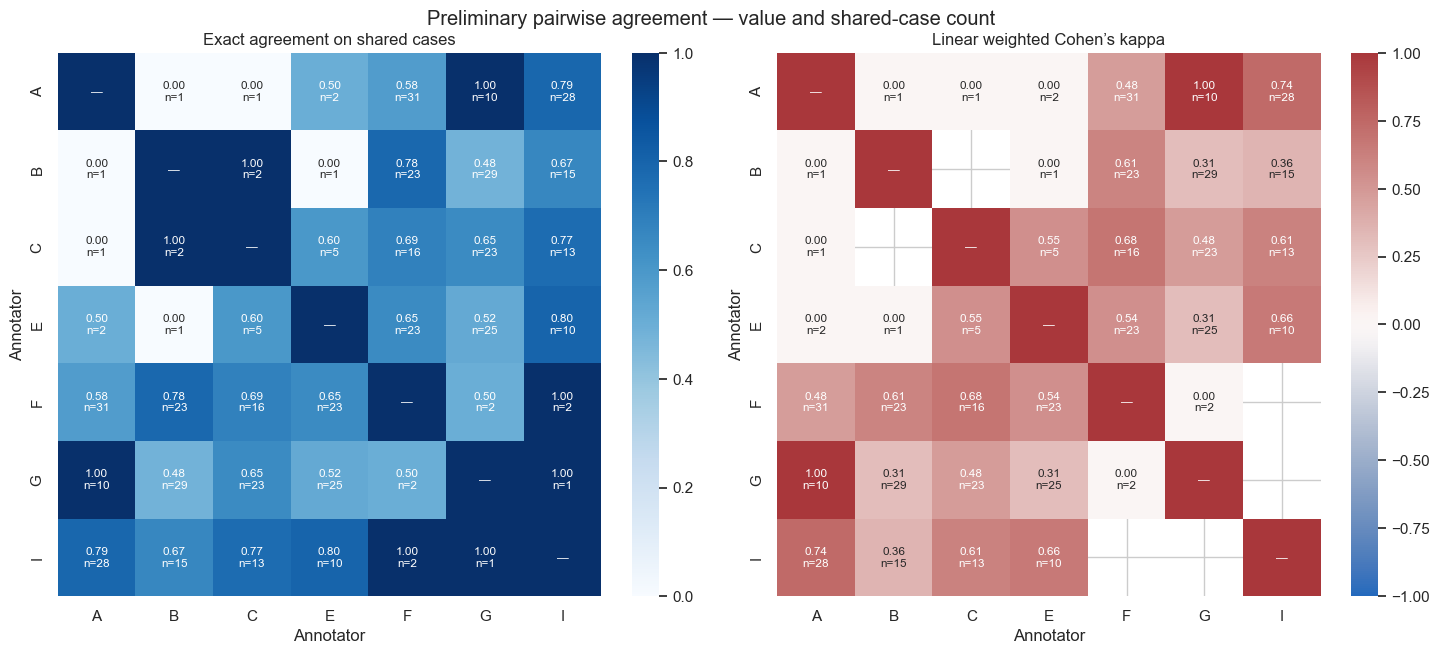

In [15]:
exact_matrix = pd.DataFrame(np.nan, index=annotators, columns=annotators)
kappa_matrix = pd.DataFrame(np.nan, index=annotators, columns=annotators)
overlap_matrix = pd.DataFrame(0, index=annotators, columns=annotators, dtype=int)
np.fill_diagonal(exact_matrix.values, 1.0)
np.fill_diagonal(kappa_matrix.values, 1.0)
np.fill_diagonal(overlap_matrix.values, 100)

for row in pairwise_summary.itertuples(index=False):
    exact_matrix.loc[row.annotator_a, row.annotator_b] = row.exact_agreement
    exact_matrix.loc[row.annotator_b, row.annotator_a] = row.exact_agreement
    kappa_matrix.loc[row.annotator_a, row.annotator_b] = row.linear_weighted_kappa
    kappa_matrix.loc[row.annotator_b, row.annotator_a] = row.linear_weighted_kappa
    overlap_matrix.loc[row.annotator_a, row.annotator_b] = row.n_shared_cases
    overlap_matrix.loc[row.annotator_b, row.annotator_a] = row.n_shared_cases

exact_annotations = exact_matrix.copy().astype(object)
kappa_annotations = kappa_matrix.copy().astype(object)
for annotator_a in annotators:
    for annotator_b in annotators:
        if annotator_a == annotator_b:
            exact_annotations.loc[annotator_a, annotator_b] = '—'
            kappa_annotations.loc[annotator_a, annotator_b] = '—'
            continue
        n_shared = int(overlap_matrix.loc[annotator_a, annotator_b])
        exact_value = exact_matrix.loc[annotator_a, annotator_b]
        kappa_value = kappa_matrix.loc[annotator_a, annotator_b]
        exact_annotations.loc[annotator_a, annotator_b] = (
            f'{exact_value:.2f}\nn={n_shared}' if np.isfinite(exact_value) else f'NA\nn={n_shared}'
        )
        kappa_annotations.loc[annotator_a, annotator_b] = (
            f'{kappa_value:.2f}\nn={n_shared}' if np.isfinite(kappa_value) else f'NA\nn={n_shared}'
        )

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), constrained_layout=True)
sns.heatmap(
    exact_matrix, vmin=0, vmax=1, cmap='Blues', annot=exact_annotations, fmt='',
    square=True, annot_kws={'fontsize': 8.5}, ax=axes[0],
)
axes[0].set_title('Exact agreement on shared cases')
axes[0].set_xlabel('Annotator')
axes[0].set_ylabel('Annotator')
sns.heatmap(
    kappa_matrix, vmin=-1, vmax=1, center=0, cmap='vlag', annot=kappa_annotations, fmt='',
    square=True, annot_kws={'fontsize': 8.5}, ax=axes[1],
)
axes[1].set_title('Linear weighted Cohen’s kappa')
axes[1].set_xlabel('Annotator')
axes[1].set_ylabel('Annotator')
fig.suptitle('Preliminary pairwise agreement — value and shared-case count', y=1.03)
fig.savefig(FIGURE_DIR / 'pairwise_agreement_heatmaps.png', dpi=220, bbox_inches='tight')
plt.show()

## 14. Overall ordinal Krippendorff’s alpha

This implementation uses the coincidence-matrix definition of Krippendorff’s alpha with ordinal distances derived from the observed category marginals. It naturally permits unequal numbers of raters and missing annotator–case combinations. Only cases with at least two current ratings contribute.

In [16]:
def krippendorff_alpha_ordinal(
    data: pd.DataFrame,
    unit_col: str = 'case_id',
    value_col: str = 'label',
    categories: list = LABEL_ORDER,
) -> dict:
    category_to_index = {category: index for index, category in enumerate(categories)}
    coincidence = np.zeros((len(categories), len(categories)), dtype=float)
    n_pairable_units = 0
    n_pairable_ratings = 0

    for _, unit in data[[unit_col, value_col]].dropna().groupby(unit_col):
        values = unit[value_col].astype(int).tolist()
        m = len(values)
        if m < 2:
            continue
        n_pairable_units += 1
        n_pairable_ratings += m
        counts = np.array([values.count(category) for category in categories], dtype=float)
        for i in range(len(categories)):
            for j in range(len(categories)):
                if i == j:
                    coincidence[i, j] += counts[i] * (counts[i] - 1.0) / (m - 1.0)
                else:
                    coincidence[i, j] += counts[i] * counts[j] / (m - 1.0)

    marginals = coincidence.sum(axis=1)
    n = float(marginals.sum())
    if n <= 1:
        return {
            'alpha_ordinal': np.nan,
            'n_pairable_units': n_pairable_units,
            'n_pairable_ratings': n_pairable_ratings,
            'observed_disagreement': np.nan,
            'expected_disagreement': np.nan,
        }

    expected = np.outer(marginals, marginals) / (n - 1.0)
    expected[np.diag_indices_from(expected)] = marginals * (marginals - 1.0) / (n - 1.0)

    distance_squared = np.zeros_like(coincidence)
    for i in range(len(categories)):
        for j in range(len(categories)):
            if i == j:
                continue
            lower, upper = sorted((i, j))
            ordinal_interval = (
                marginals[lower:upper + 1].sum()
                - 0.5 * (marginals[lower] + marginals[upper])
            )
            distance_squared[i, j] = ordinal_interval ** 2

    observed_disagreement = float((coincidence * distance_squared).sum() / n)
    expected_disagreement = float((expected * distance_squared).sum() / n)
    alpha = np.nan if expected_disagreement == 0 else 1.0 - observed_disagreement / expected_disagreement

    return {
        'alpha_ordinal': alpha,
        'n_pairable_units': n_pairable_units,
        'n_pairable_ratings': n_pairable_ratings,
        'observed_disagreement': observed_disagreement,
        'expected_disagreement': expected_disagreement,
    }


alpha_result = pd.DataFrame([krippendorff_alpha_ordinal(joined)])
alpha_result.insert(0, 'status', 'preliminary_current_annotators')
alpha_result.to_csv(OUTPUT_DIR / 'krippendorff_alpha_ordinal.csv', index=False)
display(alpha_result.round(4))

,status,alpha_ordinal,n_pairable_units,n_pairable_ratings,observed_disagreement,expected_disagreement
0,preliminary_current_annotators,0.5783,236,485,13611.3763,32276.8512


## 15. Null controls and clear high-SNR checks

Null controls are summarized separately. For high-SNR signal cases, label `3` is treated as the strict anomaly flag; label `2` is retained as a warning rather than automatically classified as an error.

In [17]:
if joined['is_null'].dtype == bool:
    is_null = joined['is_null']
else:
    is_null = joined['is_null'].astype(str).str.strip().str.lower().eq('true')

null_responses = joined.loc[is_null].copy()
null_counts = (
    null_responses.groupby(['annotator_id', 'label']).size().unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
null_summary = null_counts.rename(columns={1: 'n_label_1', 2: 'n_label_2', 3: 'n_label_3'})
null_summary['n_null'] = null_counts.sum(axis=1)
null_summary['share_label_1'] = null_counts[1] / null_summary['n_null']
null_summary['share_label_2'] = null_counts[2] / null_summary['n_null']
null_summary['share_label_3'] = null_counts[3] / null_summary['n_null']
null_summary = null_summary.reset_index()
null_summary.to_csv(OUTPUT_DIR / 'null_check_by_annotator.csv', index=False)

null_non_no = null_responses.loc[
    null_responses['label'].ne(3),
    ['plot_code', 'case_id', 'annotator_id', 'label', 'global_score', 'MIC', 'MEV', 'dCor'],
].sort_values(['annotator_id', 'label', 'plot_code'])
null_non_no.to_csv(OUTPUT_DIR / 'null_responses_not_label_3.csv', index=False)

requested_snr = pd.to_numeric(joined['requested_snr'], errors='coerce')
high_snr_mask = (~is_null) & requested_snr.ge(HIGH_SNR_THRESHOLD)
high_snr = joined.loc[high_snr_mask].copy()
high_snr_counts = (
    high_snr.groupby(['annotator_id', 'label']).size().unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
high_snr_summary = high_snr_counts.rename(columns={1: 'n_label_1', 2: 'n_label_2', 3: 'n_label_3'})
high_snr_summary['n_high_snr'] = high_snr_counts.sum(axis=1)
high_snr_summary['share_label_1'] = high_snr_counts[1] / high_snr_summary['n_high_snr']
high_snr_summary['share_label_2'] = high_snr_counts[2] / high_snr_summary['n_high_snr']
high_snr_summary['share_label_3'] = high_snr_counts[3] / high_snr_summary['n_high_snr']
high_snr_summary = high_snr_summary.reset_index()
high_snr_summary.to_csv(OUTPUT_DIR / 'high_snr_check_by_annotator.csv', index=False)

high_snr_strict_anomalies = high_snr.loc[
    high_snr['label'].eq(3),
    ['plot_code', 'case_id', 'annotator_id', 'family_id', 'family_name',
     'requested_snr', 'actual_snr', 'repeat', 'label', 'global_score', 'MIC', 'MEV', 'dCor'],
].sort_values(['annotator_id', 'family_id', 'requested_snr'], ascending=[True, True, False])
high_snr_strict_anomalies.to_csv(OUTPUT_DIR / 'high_snr_label_3_anomalies.csv', index=False)

high_snr_warnings = high_snr.loc[
    high_snr['label'].eq(2),
    ['plot_code', 'case_id', 'annotator_id', 'family_id', 'family_name',
     'requested_snr', 'actual_snr', 'repeat', 'label', 'global_score', 'MIC', 'MEV', 'dCor'],
].sort_values(['annotator_id', 'family_id', 'requested_snr'], ascending=[True, True, False])
high_snr_warnings.to_csv(OUTPUT_DIR / 'high_snr_label_2_warnings.csv', index=False)

display(Markdown('**Null controls by annotator**'))
display(null_summary.round(3))
display(Markdown(f'**High-SNR signals (requested SNR ≥ {HIGH_SNR_THRESHOLD:g}) by annotator**'))
display(high_snr_summary.round(3))
print(f'Null responses not labeled 3: {len(null_non_no)}')
print(f'High-SNR strict anomalies (label 3): {len(high_snr_strict_anomalies)}')
print(f'High-SNR uncertainty warnings (label 2): {len(high_snr_warnings)}')

**Null controls by annotator**

label,annotator_id,n_label_1,n_label_2,n_label_3,n_null,share_label_1,share_label_2,share_label_3
0,A,0,0,6,6,0.0,0.000,1.000
1,B,0,0,6,6,0.0,0.000,1.000
2,C,0,0,7,7,0.0,0.000,1.000
3,E,0,2,5,7,0.0,0.286,0.714
4,F,0,0,7,7,0.0,0.000,1.000
5,G,0,0,7,7,0.0,0.000,1.000
6,I,0,0,7,7,0.0,0.000,1.000


**High-SNR signals (requested SNR ≥ 10) by annotator**

label,annotator_id,n_label_1,n_label_2,n_label_3,n_high_snr,share_label_1,share_label_2,share_label_3
0,A,22,3,0,25,0.880,0.120,0.000
1,B,20,0,1,21,0.952,0.000,0.048
2,C,15,0,7,22,0.682,0.000,0.318
3,E,12,1,9,22,0.545,0.045,0.409
4,F,18,3,0,21,0.857,0.143,0.000
5,G,17,3,5,25,0.680,0.120,0.200
6,I,18,0,4,22,0.818,0.000,0.182


Null responses not labeled 3: 2
High-SNR strict anomalies (label 3): 26
High-SNR uncertainty warnings (label 2): 10


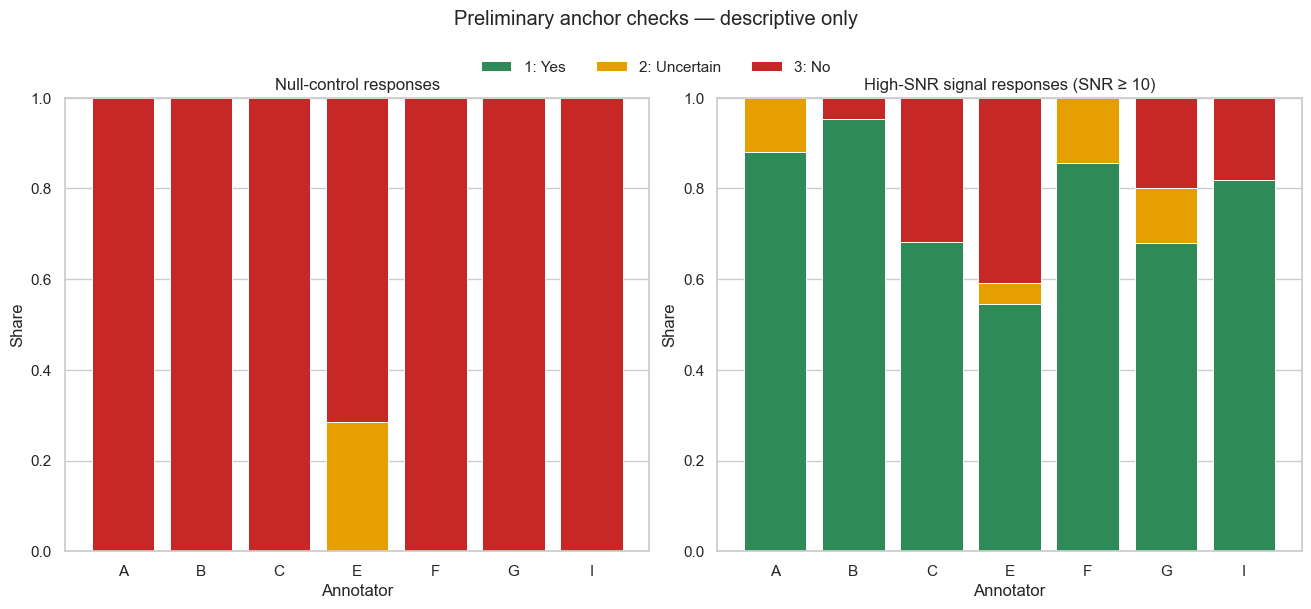

In [18]:
def stacked_profile(ax, counts: pd.DataFrame, title: str) -> None:
    proportions = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    bottom = np.zeros(len(proportions))
    for label in LABEL_ORDER:
        values = proportions[label].fillna(0).to_numpy()
        ax.bar(
            proportions.index, values, bottom=bottom,
            color=LABEL_COLORS[label], label=f'{label}: {LABEL_NAMES[label]}',
            edgecolor='white', linewidth=0.7,
        )
        bottom += values
    ax.set_ylim(0, 1)
    ax.set_xlabel('Annotator')
    ax.set_ylabel('Share')
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(13, 5.3), constrained_layout=True)
stacked_profile(axes[0], null_counts, 'Null-control responses')
stacked_profile(axes[1], high_snr_counts, f'High-SNR signal responses (SNR ≥ {HIGH_SNR_THRESHOLD:g})')
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Preliminary anchor checks — descriptive only', y=1.12)
fig.savefig(FIGURE_DIR / 'null_and_high_snr_checks.png', dpi=220, bbox_inches='tight')
plt.show()

## 16. Where disagreement is concentrated

Case-level disagreement is computed only when at least two current labels are available. These summaries are diagnostic and are **not** final consensus labels.

In [19]:
def normalized_entropy(values: pd.Series) -> float:
    probabilities = values.value_counts(normalize=True).reindex(LABEL_ORDER, fill_value=0).to_numpy(dtype=float)
    probabilities = probabilities[probabilities > 0]
    if not len(probabilities):
        return np.nan
    return float(-(probabilities * np.log(probabilities)).sum() / np.log(len(LABEL_ORDER)))


def pairwise_disagreement(values: pd.Series) -> float:
    values = values.astype(int).to_numpy()
    n = len(values)
    if n < 2:
        return np.nan
    total_pairs = n * (n - 1) / 2
    same_pairs = sum((values == label).sum() * ((values == label).sum() - 1) / 2 for label in LABEL_ORDER)
    return float(1.0 - same_pairs / total_pairs)


case_agreement = joined.groupby('case_id').agg(
    n_current_raters=('label', 'size'),
    n_label_1=('label', lambda values: int((values == 1).sum())),
    n_label_2=('label', lambda values: int((values == 2).sum())),
    n_label_3=('label', lambda values: int((values == 3).sum())),
    mean_global_score=('global_score', 'mean'),
    median_label=('label', 'median'),
    exact_unanimity=('label', lambda values: bool(values.nunique() == 1)),
    normalized_entropy=('label', normalized_entropy),
    pairwise_disagreement=('label', pairwise_disagreement),
).reset_index()

case_metadata_columns = [
    'case_id', 'family_id', 'family_name', 'requested_snr', 'nominal_snr', 'actual_snr',
    'repeat', 'MIC', 'MEV', 'dCor', 'is_null', 'snr_band', 'variant_name', 'params_json',
]
case_metadata = joined[case_metadata_columns].drop_duplicates('case_id')
case_agreement = case_agreement.merge(case_metadata, on='case_id', how='left', validate='one_to_one')
case_agreement.to_csv(OUTPUT_DIR / 'preliminary_case_agreement.csv', index=False)

multi_rated = case_agreement.loc[case_agreement['n_current_raters'].ge(2)].copy()
family_snr_disagreement = (
    multi_rated.groupby(['family_id', 'family_name', 'requested_snr'], dropna=False)
    .agg(
        n_cases=('case_id', 'size'),
        mean_current_raters=('n_current_raters', 'mean'),
        mean_pairwise_disagreement=('pairwise_disagreement', 'mean'),
        mean_entropy=('normalized_entropy', 'mean'),
        unanimous_share=('exact_unanimity', 'mean'),
        mean_global_score=('mean_global_score', 'mean'),
    )
    .reset_index()
)
family_snr_disagreement.to_csv(OUTPUT_DIR / 'disagreement_by_family_snr.csv', index=False)

high_disagreement_cases = multi_rated.loc[
    multi_rated['pairwise_disagreement'].ge(0.5)
    | ((multi_rated['n_label_1'] > 0) & (multi_rated['n_label_3'] > 0))
].sort_values(['pairwise_disagreement', 'n_current_raters'], ascending=[False, False])
high_disagreement_cases.to_csv(OUTPUT_DIR / 'high_disagreement_cases.csv', index=False)

print(f'Cases with ≥2 current labels: {len(multi_rated):,}')
print(f'Cases flagged for high disagreement/review: {len(high_disagreement_cases):,}')
display(high_disagreement_cases.head(25).round(3))

Cases with ≥2 current labels: 236
Cases flagged for high disagreement/review: 80


,case_id,n_current_raters,n_label_1,n_label_2,n_label_3,mean_global_score,median_label,exact_unanimity,normalized_entropy,pairwise_disagreement,family_id,family_name,requested_snr,nominal_snr,actual_snr,repeat,MIC,MEV,dCor,is_null,snr_band,variant_name,params_json
110,S018482,3,1,1,1,0.50,2.0,False,1.000,1.0,F05,Power concave positive,0.5,0.492,0.432,2,0.274,0.274,0.437,False,middle_low_1.5_to_0.3,p_0.15,"{""p"": 0.15}"
19,N066,2,0,1,1,0.25,2.5,False,0.631,1.0,Null,No relationship,NaN,NaN,NaN,66,0.176,0.176,0.071,True,NaN,independent_normal,{}
24,N080,2,0,1,1,0.25,2.5,False,0.631,1.0,Null,No relationship,NaN,NaN,NaN,80,0.163,0.163,0.066,True,NaN,independent_normal,{}
47,S004859,2,1,0,1,0.50,2.0,False,0.631,1.0,F01,Linear positive,0.4,0.404,0.374,2,0.382,0.382,0.546,False,middle_low_1.5_to_0.3,slope_3,"{""intercept"": 0.0, ""slope"": 3.0}"
63,S011445,2,1,0,1,0.50,2.0,False,0.631,1.0,F03,Power convex positive,0.5,0.492,0.528,1,0.330,0.330,0.515,False,middle_low_1.5_to_0.3,p_4,"{""p"": 4.0}"
66,S011462,2,1,1,0,0.75,1.5,False,0.631,1.0,F03,Power convex positive,1.5,1.509,1.620,1,0.508,0.508,0.698,False,middle_low_1.5_to_0.3,p_4,"{""p"": 4.0}"
67,S011466,2,1,0,1,0.50,2.0,False,0.631,1.0,F03,Power convex positive,2.0,1.965,2.109,1,0.570,0.570,0.734,False,middle_high_7_to_2,p_4,"{""p"": 4.0}"
76,S011664,2,1,0,1,0.50,2.0,False,0.631,1.0,F03,Power convex positive,0.3,0.290,0.338,2,0.316,0.316,0.431,False,middle_low_1.5_to_0.3,p_4,"{""p"": 4.0}"
81,S011689,2,1,1,0,0.75,1.5,False,0.631,1.0,F03,Power convex positive,1.5,1.509,1.758,2,0.490,0.490,0.689,False,middle_low_1.5_to_0.3,p_4,"{""p"": 4.0}"
93,S018252,2,1,1,0,0.75,1.5,False,0.631,1.0,F05,Power concave positive,0.4,0.404,0.361,1,0.304,0.304,0.460,False,middle_low_1.5_to_0.3,p_0.15,"{""p"": 0.15}"


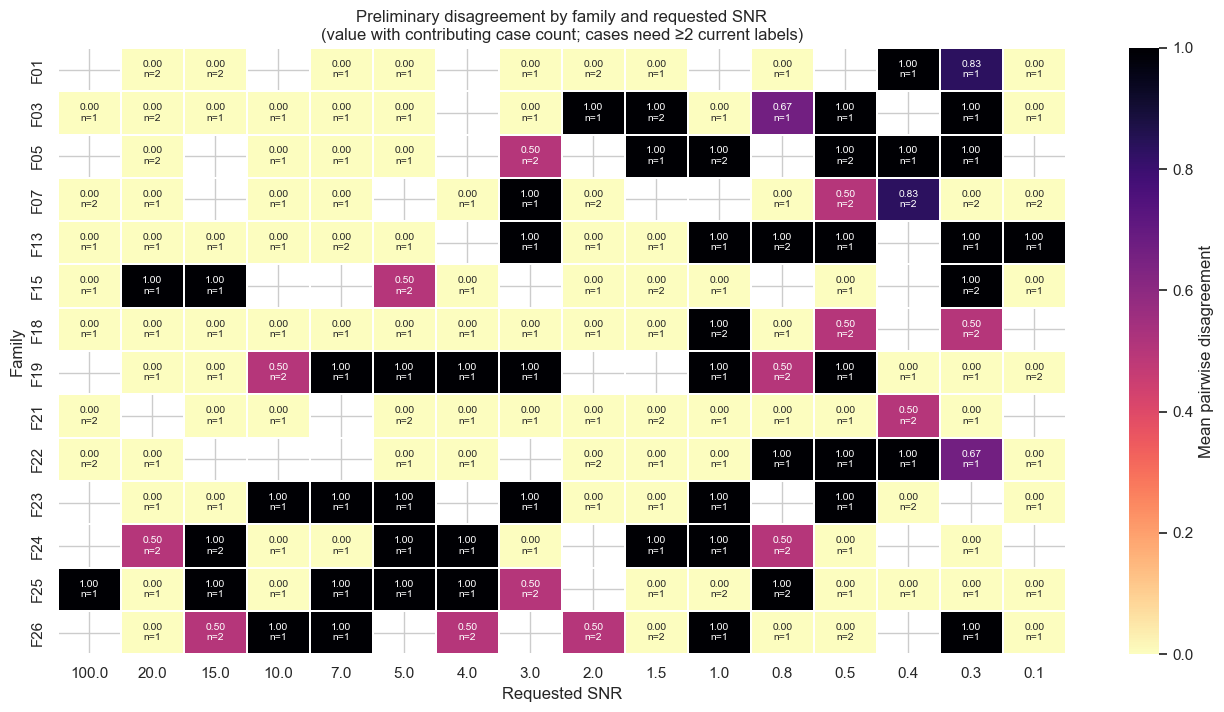

In [20]:
signal_disagreement = family_snr_disagreement.loc[family_snr_disagreement['family_id'].ne('Null')].copy()
heatmap_data = signal_disagreement.pivot(
    index='family_id', columns='requested_snr', values='mean_pairwise_disagreement'
)
heatmap_n = signal_disagreement.pivot(
    index='family_id', columns='requested_snr', values='n_cases'
)
snr_columns = sorted([column for column in heatmap_data.columns if pd.notna(column)], reverse=True)
heatmap_data = heatmap_data.reindex(columns=snr_columns)
heatmap_n = heatmap_n.reindex(index=heatmap_data.index, columns=snr_columns)

heatmap_annotations = pd.DataFrame('', index=heatmap_data.index, columns=heatmap_data.columns)
for family_id in heatmap_data.index:
    for requested_snr_value in heatmap_data.columns:
        value = heatmap_data.loc[family_id, requested_snr_value]
        n_cases = heatmap_n.loc[family_id, requested_snr_value]
        if np.isfinite(value):
            heatmap_annotations.loc[family_id, requested_snr_value] = f'{value:.2f}\nn={int(n_cases)}'

fig_width = max(13, 0.84 * len(heatmap_data.columns))
fig_height = max(6.5, 0.52 * len(heatmap_data.index))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.heatmap(
    heatmap_data,
    vmin=0, vmax=1, cmap='magma_r',
    annot=heatmap_annotations, fmt='', annot_kws={'fontsize': 7.5}, linewidths=0.35,
    cbar_kws={'label': 'Mean pairwise disagreement'},
    ax=ax,
)
ax.set_title('Preliminary disagreement by family and requested SNR\n(value with contributing case count; cases need ≥2 current labels)')
ax.set_xlabel('Requested SNR')
ax.set_ylabel('Family')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'disagreement_by_family_snr.png', dpi=220, bbox_inches='tight')
plt.show()

## 17. Output inventory

The primary long-format output is `annotation_responses_joined.csv`. All other files are preliminary QC summaries or diagnostic figures.

In [21]:
output_inventory = []
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        output_inventory.append({
            'file': str(path.relative_to(OUTPUT_DIR)),
            'size_kb': round(path.stat().st_size / 1024, 1),
        })
output_inventory = pd.DataFrame(output_inventory)
display(output_inventory)

print('\nPRELIMINARY ONLY: final consensus and final metric calibration should wait for the remaining annotators.')

,file,size_kb
0,.DS_Store,8.0
1,annotation_responses_joined.csv,326.1
2,annotator_contact_sheet_manifest.csv,1.5
3,annotator_label_distribution.csv,0.5
4,case_level_annotation_consensus.csv,72.8
5,combined_group_case_response_map.csv,22.2
6,combined_group_label_map_manifest.csv,1.0
7,coverage_distribution.csv,0.0
8,coverage_summary.csv,0.1
9,disagreement_by_family_snr.csv,9.8



PRELIMINARY ONLY: final consensus and final metric calibration should wait for the remaining annotators.
